# Análise de Resultados — TCC I
## Avaliação do Trade-off entre Taxa de Captura, Consumo de Recursos e Disponibilidade de Imagens Adequadas em um Pipeline Edge AI para Estimativa de Peso de Ovinos

**Autor:** *(preencher)*  
**Data:** *(preencher)*  
**Hardware:** Raspberry Pi 5 — 16 GB RAM  
**FPS avaliados:** 1, 2, 3, 4, 5, 10, 15, 20, 30  

---
> **Estrutura esperada dos dados:**
> ```
> infra/reports/
>   pre_1_FPS/   cpu.csv  mem.csv  temp.csv  metrics.json  report.md
>   pre_2_FPS/   ...
>   ...
>   pre_30_FPS/  ...
> ```
> Ajuste `BASE_DIR` na célula de configuração caso necessário.


## 0. Imports e Configuração

In [ ]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

# ── Configuração ─────────────────────────────────────────────────────────
BASE_DIR = Path("../infra/reports")   # <-- ajuste se necessário

FPS_LIST = [1, 2, 3, 4, 5, 10, 15, 20, 30]

# Paleta de cores consistente ao longo do notebook
PALETTE = plt.cm.viridis(np.linspace(0.15, 0.9, len(FPS_LIST)))
FPS_COLOR = {fps: PALETTE[i] for i, fps in enumerate(FPS_LIST)}

# Estilo geral
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
})

print("Configuração carregada.")
print(f"Diretório base: {BASE_DIR.resolve()}")


Configuração carregada.
Diretório base: /Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports


---
## 1. Carregamento e Consolidação dos Dados

Lê as 9 pastas de FPS e produz dois dataframes:
- **`df_animals`** — uma linha por animal por FPS (do `metrics.json`)
- **`df_ts`** — séries temporais de CPU, RAM e temperatura (um ponto por segundo)


In [ ]:
def fps_from_folder(folder: Path) -> int:
    """Extrai o valor de FPS do nome da pasta (pre_10_FPS → 10)."""
    m = re.search(r"pre_(\d+)_FPS", folder.name)
    return int(m.group(1)) if m else -1


def load_metrics(folder: Path, fps: int) -> pd.DataFrame:
    """Carrega metrics.json e retorna DataFrame por animal."""
    with open(folder / "metrics.json") as f:
        raw = json.load(f)

    animals_data = raw.get("animals", {})
    rows = []
    for animal_id, info in animals_data.items():
        first_cap = pd.to_datetime(info.get("first_image_capture_time"))
        last_cap  = pd.to_datetime(info.get("last_image_capture_time"))
        pred_end  = pd.to_datetime(info.get("weight_prediction_final"))

        # Tempo de passagem do animal (s)
        passage_time_s = (last_cap - first_cap).total_seconds() if (
            first_cap and last_cap) else np.nan

        # Tempo total acumulado de inferência de peso (s)
        imgs = info.get("imgs", {})
        pred_time_s = 0.0
        for img_info in imgs.values():
            t_start = pd.to_datetime(img_info.get("weight_prediction_start"))
            t_end   = pd.to_datetime(img_info.get("weight_prediction_final"))
            if t_start and t_end:
                pred_time_s += (t_end - t_start).total_seconds()

        # Tempo total do animal (captura → última predição)
        total_animal_time_s = (pred_end - first_cap).total_seconds() if (
            pred_end and first_cap) else np.nan

        rows.append({
            "fps":              fps,
            "animal_id":        animal_id,
            "total_images":     info.get("total_of_images", 0),
            "suited_images":    info.get("suitable_images", 0),
            "passage_time_s":   passage_time_s,
            "pred_time_s":      pred_time_s,
            "total_animal_time_s": total_animal_time_s,
        })

    df = pd.DataFrame(rows)
    df["conversion_rate"] = df["suited_images"] / df["total_images"].replace(0, np.nan)
    # Throughput: frames adequados por segundo de inferência
    df["throughput_suited_ps"] = df["suited_images"] / df["pred_time_s"].replace(0, np.nan)
    return df


def load_timeseries(folder: Path, fps: int) -> pd.DataFrame:
    """Carrega cpu/mem/temp e retorna série temporal unificada."""
    cpu  = pd.read_csv(folder / "cpu.csv",  parse_dates=["timestamp"])
    mem  = pd.read_csv(folder / "mem.csv",  parse_dates=["timestamp"])
    temp = pd.read_csv(folder / "temp.csv", parse_dates=["timestamp"])

    # CPU média entre os cores
    cpu_cols = [c for c in cpu.columns if c != "timestamp"]
    cpu["cpu_mean"] = cpu[cpu_cols].mean(axis=1)
    cpu["cpu_max"]  = cpu[cpu_cols].max(axis=1)

    # RAM em GB
    mem["ram_used_gb"] = mem["used"] / 1e9
    mem["ram_pct"]     = mem["percent"]

    # Merge em timestamp (nearest, tolerância 2 s)
    df = pd.merge_asof(
        cpu[["timestamp", "cpu_mean", "cpu_max"]].sort_values("timestamp"),
        mem[["timestamp", "ram_used_gb", "ram_pct"]].sort_values("timestamp"),
        on="timestamp", tolerance=pd.Timedelta("2s"), direction="nearest"
    )
    df = pd.merge_asof(
        df.sort_values("timestamp"),
        temp[["timestamp", "temperature"]].sort_values("timestamp"),
        on="timestamp", tolerance=pd.Timedelta("2s"), direction="nearest"
    )

    # Tempo relativo em segundos a partir do início da execução
    t0 = df["timestamp"].min()
    df["t_rel_s"] = (df["timestamp"] - t0).dt.total_seconds()
    df["fps"] = fps
    return df


# ── Carregamento de todas as pastas ──────────────────────────────────────
animal_frames = []
ts_frames     = []
missing       = []

for fps in FPS_LIST:
    folder = BASE_DIR / f"pre_{fps}_FPS"
    if not folder.exists():
        print(f"  [AVISO] Pasta não encontrada: {folder}")
        missing.append(fps)
        continue
    try:
        animal_frames.append(load_metrics(folder, fps))
        ts_frames.append(load_timeseries(folder, fps))
        print(f"  ✓ {fps:2d} FPS carregado  —  {len(animal_frames[-1])} animais")
    except Exception as e:
        print(f"  [ERRO] {fps} FPS: {e}")
        missing.append(fps)

df_animals = pd.concat(animal_frames, ignore_index=True)
df_ts      = pd.concat(ts_frames,     ignore_index=True)

fps_available = sorted(df_animals["fps"].unique().tolist())

print(f"\nFPS disponíveis: {fps_available}")
print(f"Total de registros (animais × FPS): {len(df_animals)}")
print(f"Comprimento total das séries temporais: {len(df_ts)} amostras")


  ✓  1 FPS carregado  —  184 animais
  ✓  2 FPS carregado  —  184 animais
  ✓  3 FPS carregado  —  184 animais
  ✓  4 FPS carregado  —  184 animais
  ✓  5 FPS carregado  —  184 animais
  ✓ 10 FPS carregado  —  184 animais
  ✓ 15 FPS carregado  —  184 animais
  ✓ 20 FPS carregado  —  184 animais
  ✓ 30 FPS carregado  —  184 animais

FPS disponíveis: [1, 2, 3, 4, 5, 10, 15, 20, 30]
Total de registros (animais × FPS): 1656
Comprimento total das séries temporais: 13972 amostras


In [ ]:
display(df_animals)

In [54]:
# ------------------------------------------------------------
# Tabela consolidada para o artigo
# ------------------------------------------------------------

tabela_artigo = (
    df_summary[
        [
            "fps",
            "total_imgs_mean",
            "suited_imgs_mean",
            "cpu_mean",
            "ram_pct_mean",
            "temp_mean",
        ]
    ]
    .merge(
        lat_summary[["fps", "mean_latency"]],
        on="fps",
        how="left"
    )
    .rename(
        columns={
            "fps": "FPS",
            "total_imgs_mean": "Total",
            "suited_imgs_mean": "Adequados",
            "cpu_mean": "CPU (%)",
            "ram_pct_mean": "RAM (%)",
            "temp_mean": "Temp. (°C)",
            "mean_latency": "Latência (s)",
        }
    )
    .round(2)
)

display(tabela_artigo)

,FPS,Total,Adequados,CPU (%),RAM (%),Temp. (°C),Latência (s)
0,1,8.14,0.95,1.88,4.11,47.92,1.01
1,2,15.81,1.92,3.76,4.20,49.63,0.50
2,3,23.46,2.85,5.63,4.21,55.07,0.34
3,4,31.07,3.84,7.58,4.29,56.81,0.26
4,5,38.82,4.75,9.42,4.29,57.08,0.21
5,10,77.03,9.55,21.01,4.53,61.31,0.20
6,15,115.23,14.29,32.97,4.74,65.77,0.60
7,20,153.48,19.03,44.86,4.97,69.81,1.48
8,30,229.95,28.52,61.98,6.13,75.29,13.90


In [55]:
# ------------------------------------------------------------
# Exportação da tabela para LaTeX
# ------------------------------------------------------------

latex_table = tabela_artigo.to_latex(
    index=False,
    float_format="%.2f",
    caption=(
        "Resumo dos resultados obtidos para cada configuração de FPS, "
        "incluindo disponibilidade de imagens adequadas, consumo de "
        "recursos computacionais e latência do pipeline."
    ),
    label="tab:resultados_fps",
    escape=False,
)

print(latex_table)

ImportError: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.

---
## 2. Imagens Capturadas e Suited Frames por FPS

**Pergunta central:** como o FPS afeta o volume de frames processados e a quantidade de imagens adequadas obtidas por animal?


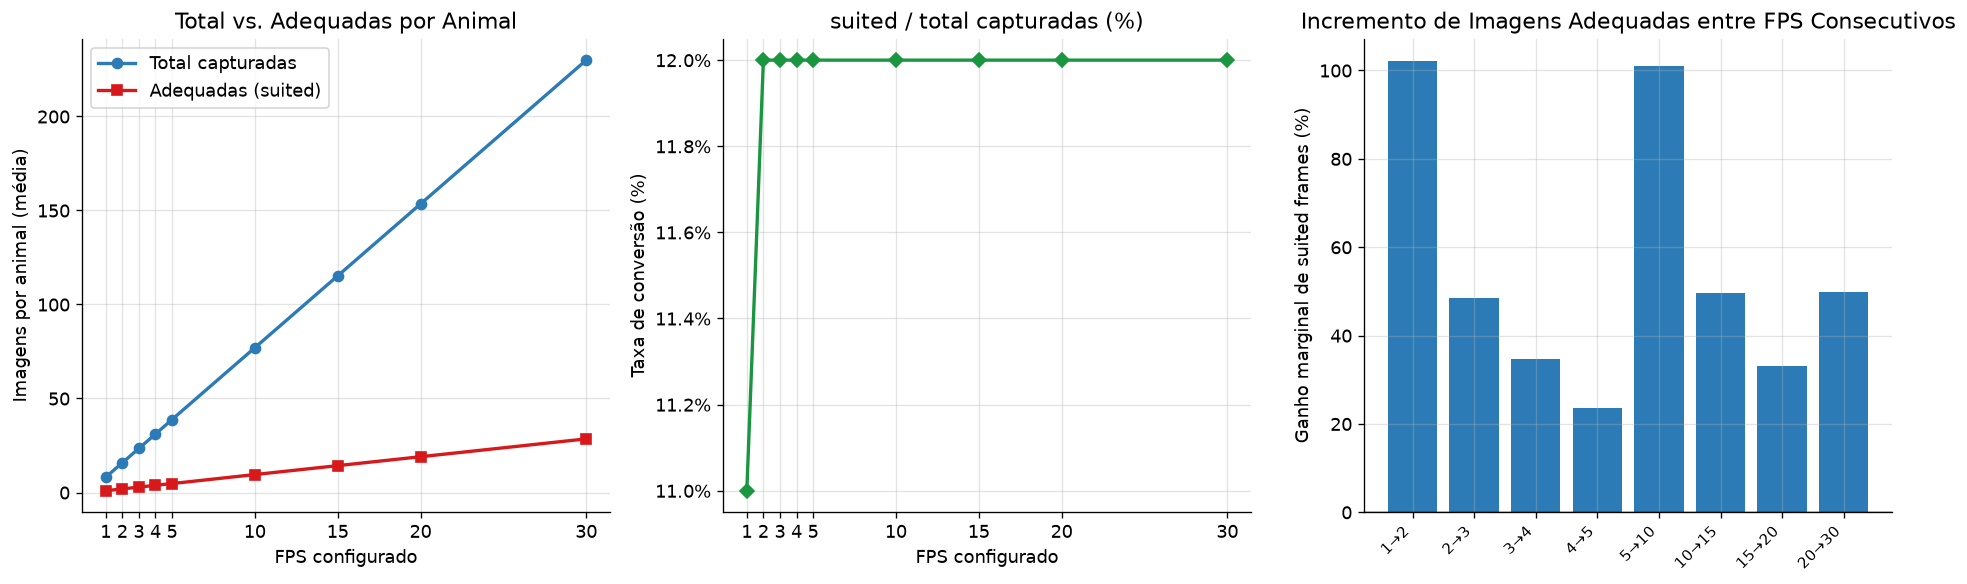

Figura salva: fig2_suited_frames.pdf


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fps_vals = df_summary["fps"].values

# ── 2a. Total de imagens vs suited (linha dupla) ─────────────────────────
ax = axes[0]
ax.plot(fps_vals, df_summary["total_imgs_mean"],
        marker="o", color="#2c7bb6", linewidth=2, label="Total capturadas")
ax.plot(fps_vals, df_summary["suited_imgs_mean"],
        marker="s", color="#d7191c", linewidth=2, label="Adequadas (suited)")
ax.set_xlabel("FPS configurado")
ax.set_ylabel("Imagens por animal (média)")
ax.set_title("Total vs. Adequadas por Animal")
ax.legend()
ax.set_xticks(fps_vals)

# ── 2b. Taxa de conversão suited/total ───────────────────────────────────
ax = axes[1]
ax.plot(fps_vals, df_summary["conversion_mean"] * 100,
        marker="D", color="#1a9641", linewidth=2)
ax.set_xlabel("FPS configurado")
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("suited / total capturadas (%)")
ax.set_xticks(fps_vals)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

# ── 2c. Ganho marginal de suited frames ──────────────────────────────────
suited_vals = df_summary["suited_imgs_mean"].values
marginal_gain = np.diff(suited_vals) / suited_vals[:-1] * 100  # %
fps_mid = [(fps_vals[i] + fps_vals[i+1]) / 2 for i in range(len(fps_vals)-1)]

ax = axes[2]
bars = ax.bar(range(len(marginal_gain)), marginal_gain,
              color=["#2c7bb6" if g > 0 else "#d7191c" for g in marginal_gain])
ax.set_xticks(range(len(marginal_gain)))
ax.set_xticklabels(
    [f"{fps_vals[i]}→{fps_vals[i+1]}" for i in range(len(fps_vals)-1)],
    rotation=45, ha="right", fontsize=9
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Ganho marginal de suited frames (%)")
ax.set_title("Incremento de Imagens Adequadas entre FPS Consecutivos")

plt.tight_layout()
plt.savefig("fig2_suited_frames.pdf", bbox_inches="tight")
plt.show()
print("Figura salva: fig2_suited_frames.pdf")


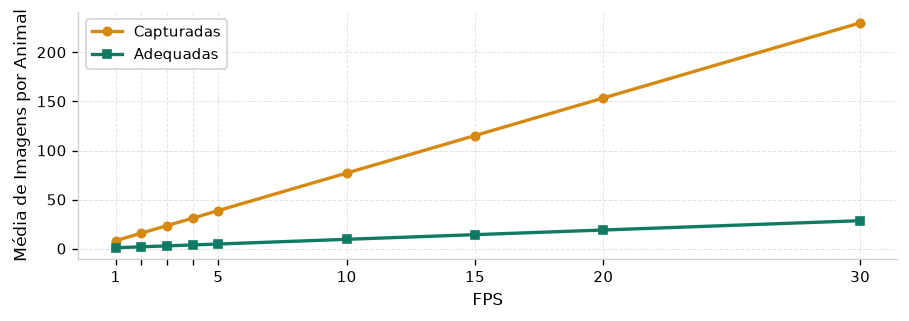

In [63]:
# ------------------------------------------------------------
# Figura: Imagens Capturadas e Adequadas por FPS
# Preparada para exportação em artigo SBC / Overleaf
# Layout Panorâmico (Wide) e Fontes Padronizadas (+1pt)
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# --- PADRÕES DE FONTE (+1 pt) ---
TITLE_FONT  = 11
LABEL_FONT  = 10
TICK_FONT   = 9
LEGEND_FONT = 9

fps_vals = df_summary["fps"].values

TOTAL_COLOR  = "#d68910" # dourado  
SUITED_COLOR = "#117a65" # verde escuro

# Largura 7.5 polegadas (wide) padronizada com as demais
fig, ax = plt.subplots(
    figsize=(7.5, 2.6)
)

ax.plot(
    fps_vals,
    df_summary["total_imgs_mean"],
    label="Capturadas",
    color=TOTAL_COLOR,
    linestyle="-",
    marker="o",
    linewidth=2.0, # Aumentado de 1.8 para 2.0
    markersize=5,  # Aumentado de 4 para 5
)

ax.plot(
    fps_vals,
    df_summary["suited_imgs_mean"],
    label="Adequadas",
    color=SUITED_COLOR,
    linestyle="-",
    marker="s",
    linewidth=2.0, # Aumentado de 1.8 para 2.0
    markersize=5,  # Aumentado de 4 para 5
)

ax.set_xlabel(
    "FPS",
    fontsize=LABEL_FONT,
)

ax.set_ylabel(
    "Média de Imagens por Animal",
    fontsize=LABEL_FONT,
)

ax.set_xticks(fps_vals)

ax.set_xticklabels([
    "" if v in (2, 3, 4) else str(v)
    for v in fps_vals
])

ax.tick_params(
    axis="both",
    labelsize=TICK_FONT,
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.35,
    linewidth=0.6,
)

for spine in ax.spines.values():
    spine.set_color("#d0d0d0")

ax.legend(
    fontsize=LEGEND_FONT,
    frameon=True,
    framealpha=0.95,
    edgecolor="#d0d0d0",
    loc="upper left",
)

plt.tight_layout(pad=0.4)

plt.savefig(
    "fig2_frames_vs_fps.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.show()


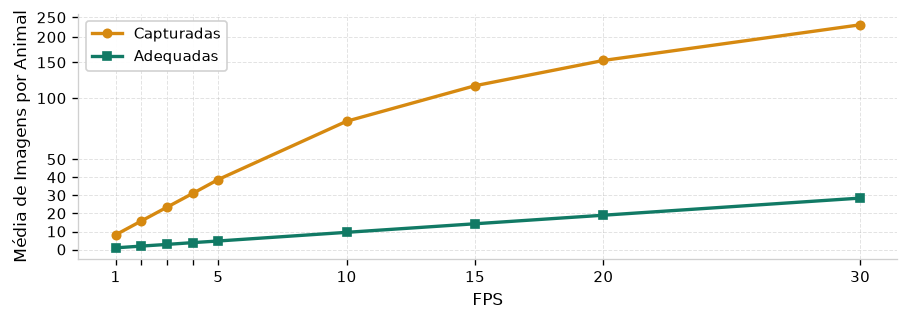

In [59]:
# ------------------------------------------------------------
# Figura: Imagens Capturadas e Adequadas por FPS
# Preparada para exportação em artigo SBC / Overleaf
# Layout Panorâmico (Wide) e Fontes Padronizadas (+1pt)
# Eixo Y com escala Symlog suavizada
# ------------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter 

# --- PADRÕES DE FONTE (+1 pt) ---
TITLE_FONT  = 11
LABEL_FONT  = 10
TICK_FONT   = 9
LEGEND_FONT = 9

fps_vals = df_summary["fps"].values

TOTAL_COLOR  = "#d68910" # dourado  
SUITED_COLOR = "#117a65" # verde escuro

fig, ax = plt.subplots(
    figsize=(7.5, 2.6)
)

ax.plot(
    fps_vals,
    df_summary["total_imgs_mean"],
    label="Capturadas",
    color=TOTAL_COLOR,
    linestyle="-",
    marker="o",
    linewidth=2.0, 
    markersize=5,  
)

ax.plot(
    fps_vals,
    df_summary["suited_imgs_mean"],
    label="Adequadas",
    color=SUITED_COLOR,
    linestyle="-",
    marker="s",
    linewidth=2.0, 
    markersize=5,  
)

ax.set_xlabel(
    "FPS",
    fontsize=LABEL_FONT,
)

ax.set_ylabel(
    "Média de Imagens por Animal",
    fontsize=LABEL_FONT,
)

# ------------------------------------------------------------
# ESCALA SYMLOG BALANCEADA
# linscale controla a proporção de espaço visual entre 
# a área linear (0-50) e a logarítmica (>50).
# ------------------------------------------------------------
ax.set_yscale("symlog", linthresh=50, linscale=0.4)

max_y = int(df_summary["total_imgs_mean"].max())
custom_yticks = [0, 10, 20, 30, 40, 50]

if max_y > 50:
    custom_yticks += list(range(100, max_y + 50, 50))

ax.set_yticks(custom_yticks)
ax.yaxis.set_major_formatter(ScalarFormatter())

# ------------------------------------------------------------
# Ajuste do Eixo X
# ------------------------------------------------------------
ax.set_xticks(fps_vals)
ax.set_xticklabels([
    "" if v in (2, 3, 4) else str(v)
    for v in fps_vals
])

ax.tick_params(
    axis="both",
    labelsize=TICK_FONT,
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.35,
    linewidth=0.6,
)

for spine in ax.spines.values():
    spine.set_color("#d0d0d0")

ax.legend(
    fontsize=LEGEND_FONT,
    frameon=True,
    framealpha=0.95,
    edgecolor="#d0d0d0",
    loc="upper left",
)

plt.tight_layout(pad=0.4)

plt.savefig(
    "fig2_frames_vs_fps.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.show()


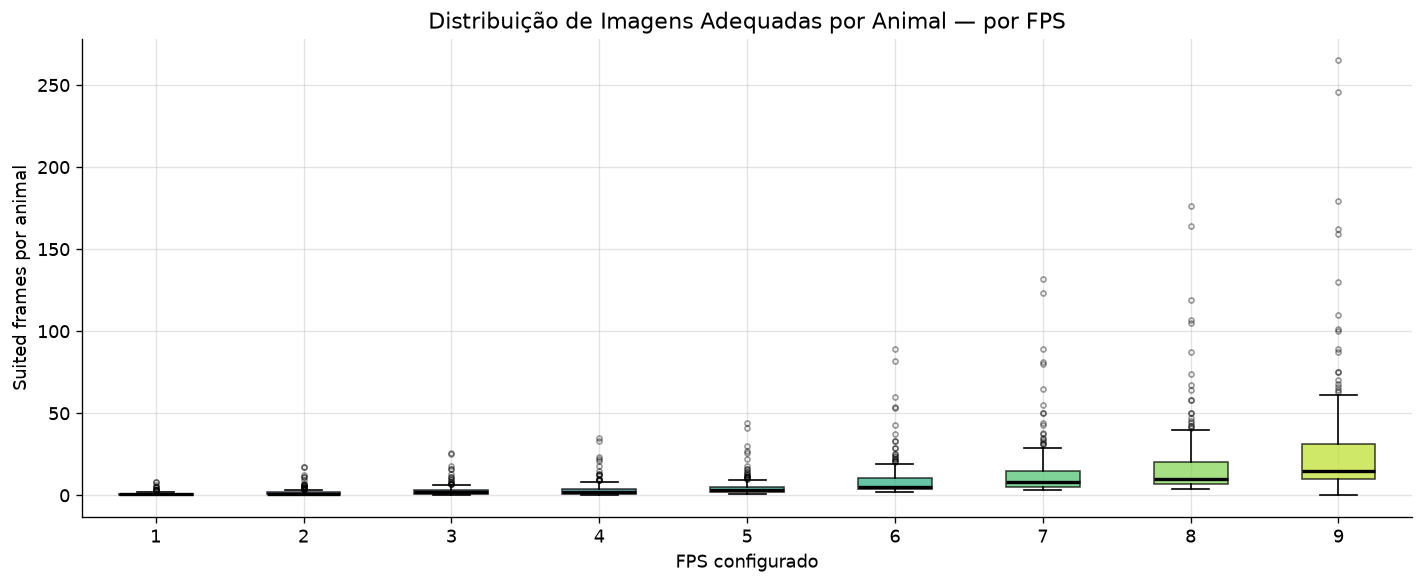

In [58]:
# ── 2d. Boxplot de suited_images por FPS (distribuição entre animais) ────
fig, ax = plt.subplots(figsize=(12, 5))

data_by_fps = [
    df_animals.loc[df_animals["fps"] == fps, "suited_images"].values
    for fps in fps_available
]

bp = ax.boxplot(
    data_by_fps,
    label=fps_available,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
for patch, fps in zip(bp["boxes"], fps_available):
    patch.set_facecolor(FPS_COLOR[fps])
    patch.set_alpha(0.7)

ax.set_xlabel("FPS configurado")
ax.set_ylabel("Suited frames por animal")
ax.set_title("Distribuição de Imagens Adequadas por Animal — por FPS")

plt.tight_layout()
plt.savefig("fig2b_boxplot_suited.pdf", bbox_inches="tight")
plt.show()


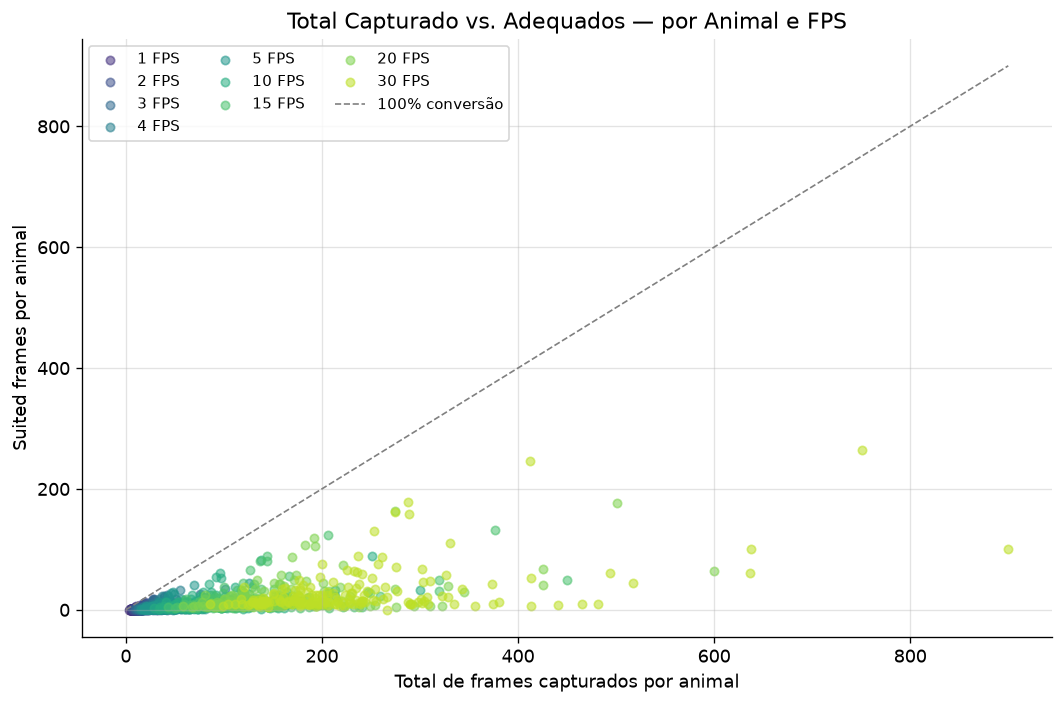

In [8]:
# ── 2e. Scatter: total_images × suited_images por animal, colorido por FPS
fig, ax = plt.subplots(figsize=(9, 6))

for fps in fps_available:
    sub = df_animals[df_animals["fps"] == fps]
    ax.scatter(sub["total_images"], sub["suited_images"],
               color=FPS_COLOR[fps], alpha=0.55, s=25, label=f"{fps} FPS")

# Linha de referência: 100% de conversão
max_tot = df_animals["total_images"].max()
ax.plot([0, max_tot], [0, max_tot], "--", color="gray",
        linewidth=1, label="100% conversão")

ax.set_xlabel("Total de frames capturados por animal")
ax.set_ylabel("Suited frames por animal")
ax.set_title("Total Capturado vs. Adequados — por Animal e FPS")
ax.legend(ncol=3, fontsize=9)

plt.tight_layout()
plt.savefig("fig2c_scatter_total_suited.pdf", bbox_inches="tight")
plt.show()


,from_fps,to_fps,gain_suited_frames,gain_per_fps
0,1,2,0.97,0.970
1,2,3,0.93,0.930
2,3,4,0.99,0.990
3,4,5,0.91,0.910
4,5,10,4.80,0.960
5,10,15,4.74,0.948
6,15,20,4.74,0.948
7,20,30,9.49,0.949


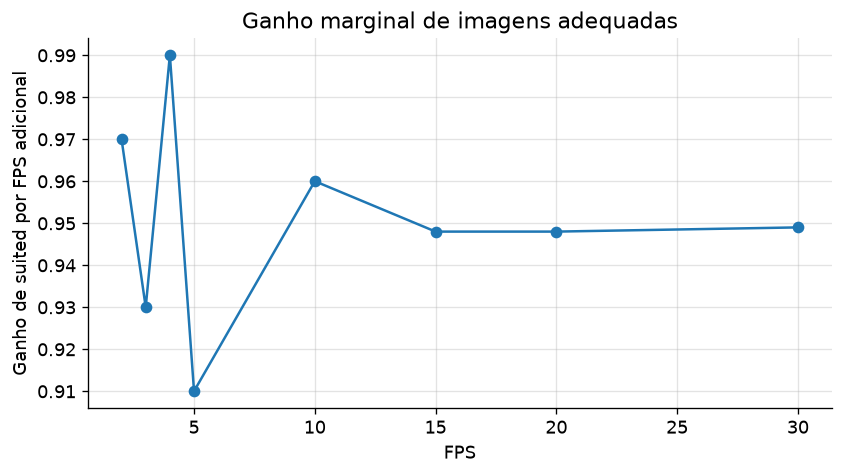

In [28]:
# ============================================================
# GANHO MARGINAL DE IMAGENS SUITED
# ============================================================

fps_values = df_summary["fps"].values
suited_values = df_summary["suited_imgs_mean"].values

marginal_gain = np.diff(suited_values)
fps_step = np.diff(fps_values)

marginal_df = pd.DataFrame({
    "from_fps": fps_values[:-1],
    "to_fps": fps_values[1:],
    "gain_suited_frames": marginal_gain,
    "gain_per_fps": marginal_gain / fps_step
})

display(marginal_df)

plt.figure(figsize=(8,4))
plt.plot(
    marginal_df["to_fps"],
    marginal_df["gain_per_fps"],
    marker="o"
)

plt.xlabel("FPS")
plt.ylabel("Ganho de suited por FPS adicional")
plt.title("Ganho marginal de imagens adequadas")
plt.grid(True)

plt.show()

---
## 3. Consumo de Recursos Computacionais

Análise de CPU, RAM e temperatura em função do FPS — tanto os valores agregados por execução quanto as séries temporais.


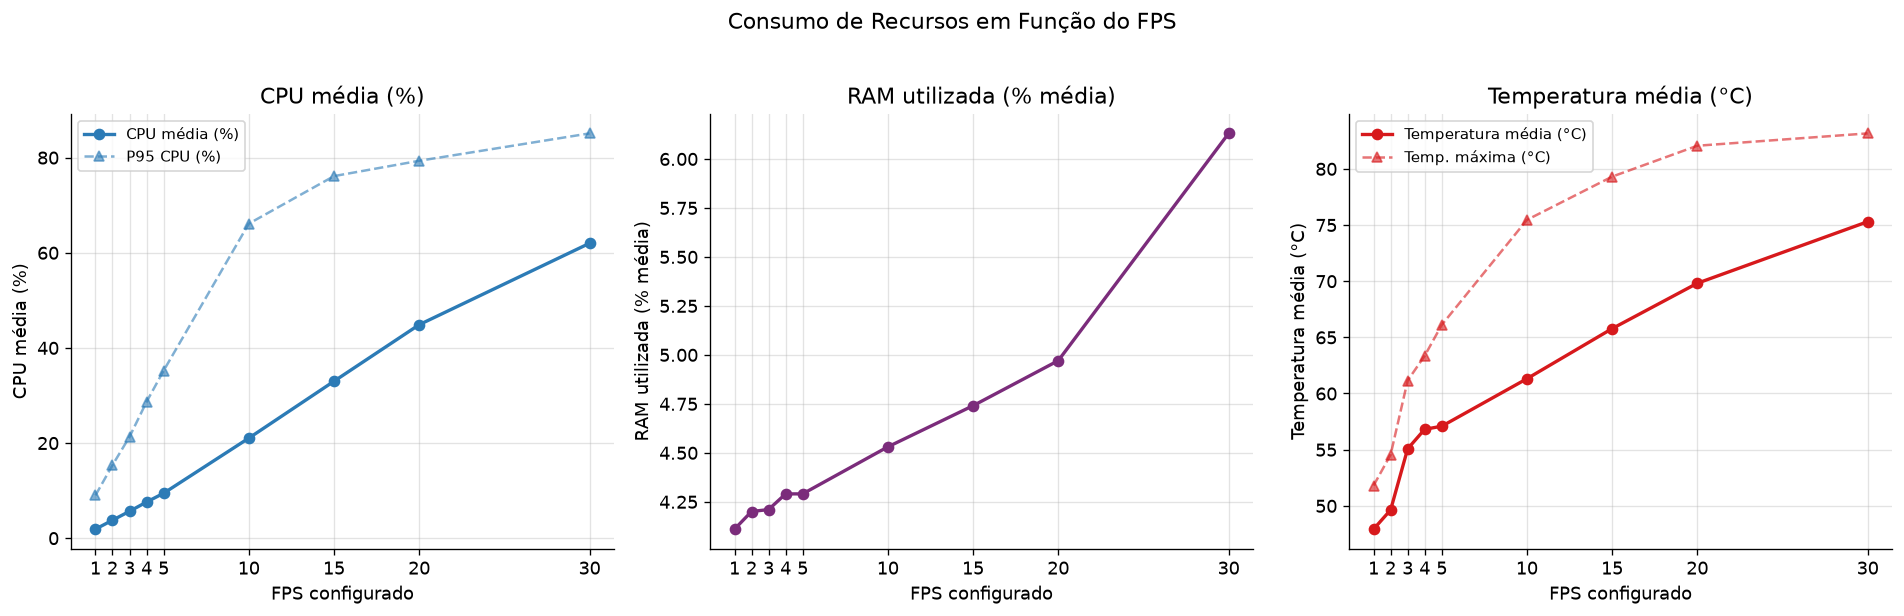

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_cfg = [
    ("cpu_mean",    "CPU média (%)",          "#2c7bb6", "cpu_p95",  "P95 CPU (%)"),
    ("ram_pct_mean","RAM utilizada (% média)", "#7b2c7b", None,       None),
    ("temp_mean",   "Temperatura média (°C)",  "#d7191c", "temp_max", "Temp. máxima (°C)"),
]

for ax, (col_mean, ylabel, color, col_extra, label_extra) in zip(axes, metrics_cfg):
    ax.plot(fps_vals, df_summary[col_mean],
            marker="o", color=color, linewidth=2, label=ylabel)
    if col_extra:
        ax.plot(fps_vals, df_summary[col_extra],
                marker="^", color=color, linewidth=1.5,
                linestyle="--", alpha=0.6, label=label_extra)
        ax.legend(fontsize=9)
    ax.set_xlabel("FPS configurado")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticks(fps_vals)

plt.suptitle("Consumo de Recursos em Função do FPS", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig3_resources_vs_fps.pdf", bbox_inches="tight")
plt.show()


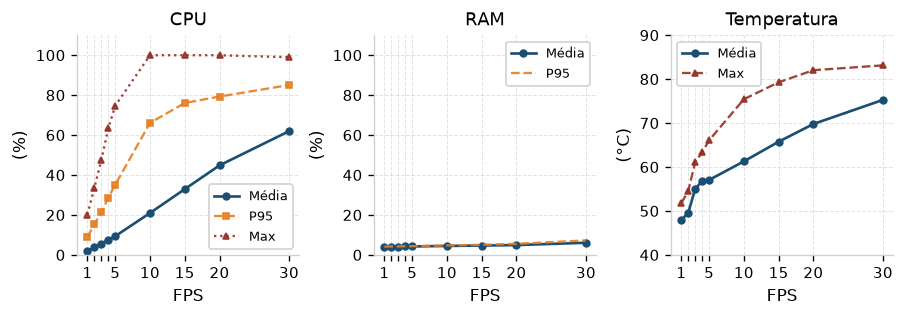

In [64]:
# ------------------------------------------------------------
# Figura: Consumo de Recursos em Função do FPS
# Preparada para exportação em artigo SBC / Overleaf
# Fontes padronizadas (+1pt) e Largura Wide (7.5 polegadas)
# Eixos independentes e linhas levemente mais finas
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# --- PADRÕES DE FONTE (+1 pt) ---
TITLE_FONT  = 11
LABEL_FONT  = 10
TICK_FONT   = 9
LEGEND_FONT = 7.5

fps_vals = df_summary["fps"]

# Cores consistentes entre os três painéis
C_MEAN = "#1b4f72"   # azul petróleo
C_P95  = "#e67e22"   # laranja queimado
C_MAX  = "#943126"   # vinho

# Usando a mesma largura (7.5) que as outras figuras para 
# padronizar o redimensionamento no LaTeX
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.5, 2.6),
    sharex=True
)

# Espessuras reduzidas (1.6 e 1.4) para um visual mais suave
# Adicionado o parâmetro 'ylim' em cada painel
metrics_cfg = [
    {
        "title": "CPU",
        "ylabel": "(%)",
        "ylim": (0, 110),
        "lines": [
            ("cpu_mean", "Média", "-",  "o", 1.6, 1.00, C_MEAN),
            ("cpu_p95",  "P95",   "--", "s", 1.4, 0.90, C_P95),
            ("cpu_max",  "Max",   ":",  "^", 1.4, 0.90, C_MAX),
        ],
    },
    {
        "title": "RAM",
        "ylabel": "(%)",
        "ylim": (0, 110),
        "lines": [
            ("ram_pct_mean", "Média", "-",  "o", 1.6, 1.00, C_MEAN),
            ("ram_pct_p95",  "P95",   "--", "",  1.4, 0.90, C_P95), # Removido o marcador como estava no seu código
        ],
    },
    {
        "title": "Temperatura",
        "ylabel": "(°C)",
        "ylim": (40, 90), # Novo limite apenas para a Temperatura
        "lines": [
            ("temp_mean", "Média", "-",  "o", 1.6, 1.00, C_MEAN),
            ("temp_max",  "Max",   "--", "^", 1.4, 0.90, C_MAX),
        ],
    },
]

for ax, cfg in zip(axes, metrics_cfg):
    for col, label, ls, marker, lw, alpha, color in cfg["lines"]:
        ax.plot(
            fps_vals, 
            df_summary[col],
            label=label,
            linestyle=ls,
            marker=marker,
            linewidth=lw,
            alpha=alpha,
            color=color,
            markersize=4, # Reduzido de 5 para 4
        )

    # Título usando a variável
    ax.set_title(cfg["title"], fontsize=TITLE_FONT, pad=6) 
    
    # Eixos usando a variável
    ax.set_xlabel("FPS", fontsize=LABEL_FONT)
    ax.set_ylabel(cfg["ylabel"], fontsize=LABEL_FONT)

    # Aplica o limite específico do Y deste painel
    ax.set_ylim(cfg["ylim"])
    
    # Ticks usando a variável e omitindo os indesejados
    ax.set_xticks(fps_vals)
    ax.set_xticklabels([
        "1",
        "",
        "",
        "",
        "5",
        "10",
        "15",
        "20",
        "30",
    ])
    ax.tick_params(axis="both", labelsize=TICK_FONT)

    ax.grid(True, linestyle="--", alpha=0.35, linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_color("#d0d0d0")

    # Legenda usando a variável
    ax.legend(
        fontsize=LEGEND_FONT, 
        frameon=True, 
        framealpha=0.95, 
        edgecolor="#d0d0d0", 
        loc="best"
    )

plt.tight_layout(pad=0.5) 
plt.savefig("fig3_resources_vs_fps.pdf", format="pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()


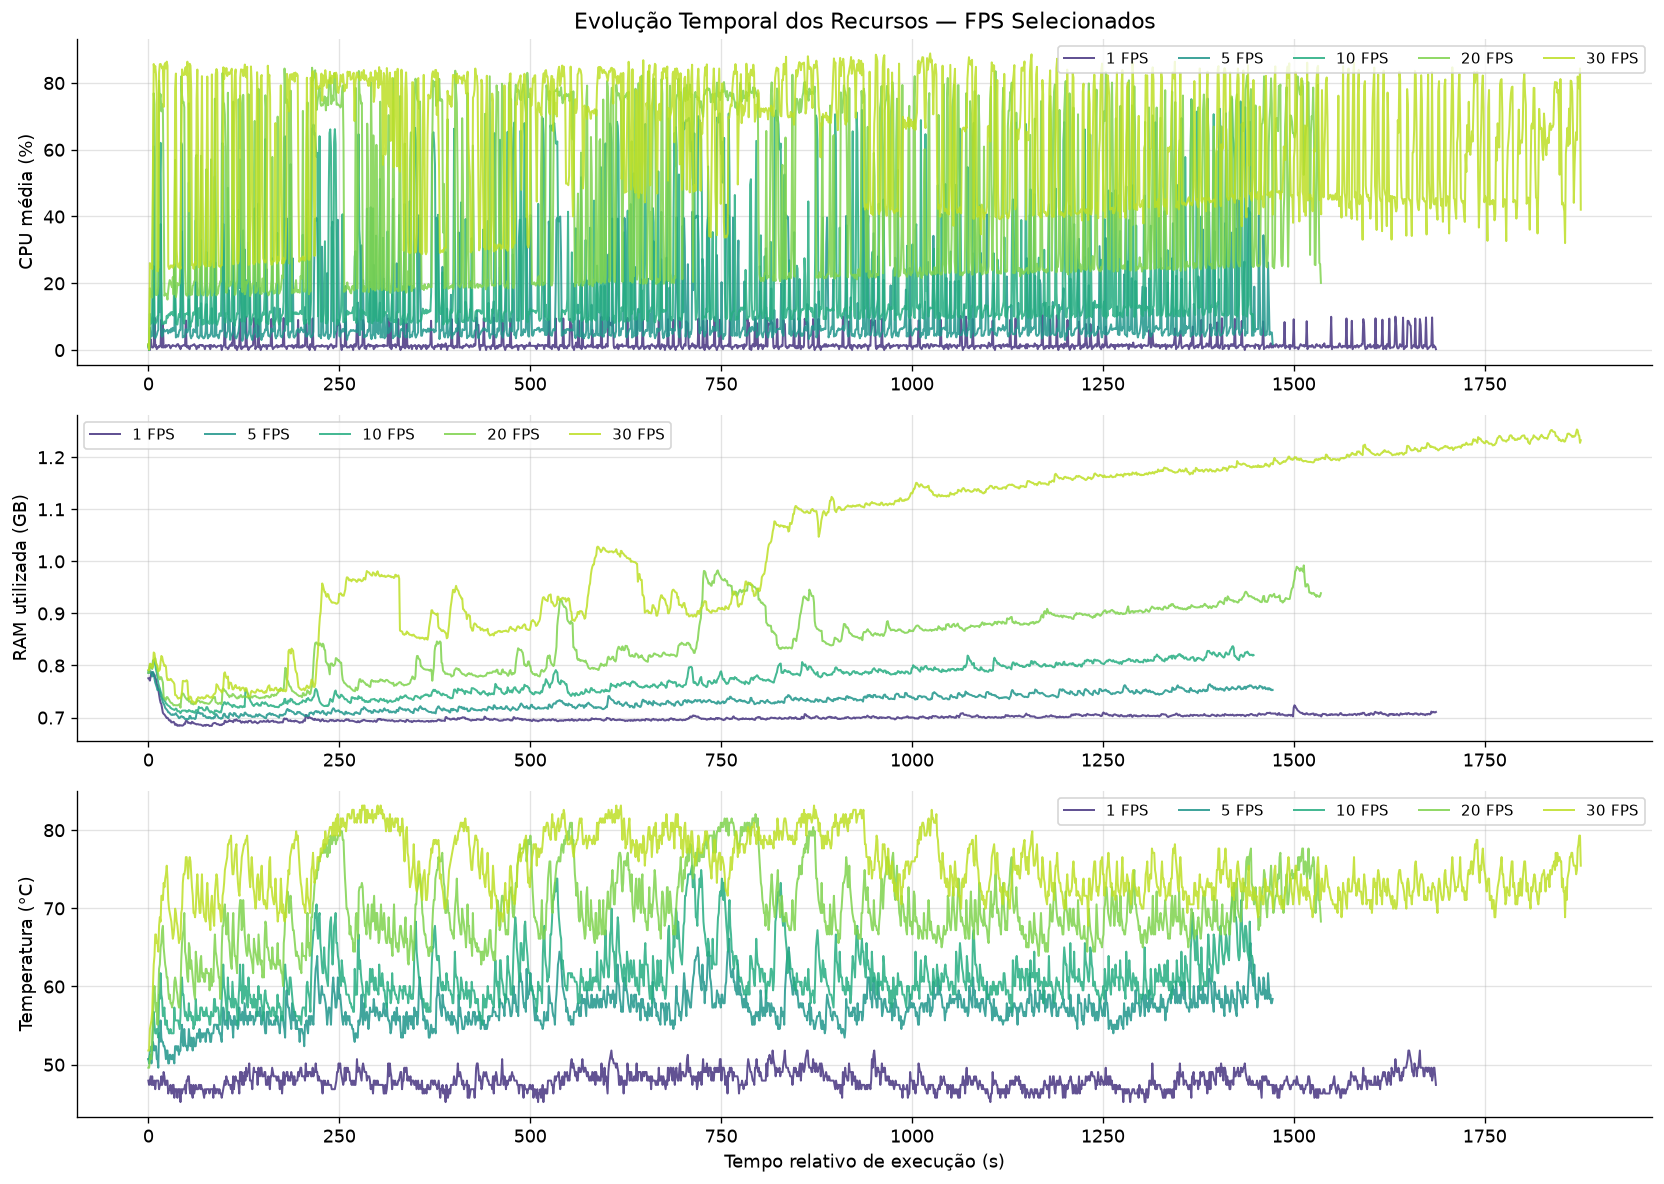

In [10]:
# ── 3b. Séries temporais sobrepostas para FPS de interesse ───────────────
FPS_HIGHLIGHT = [fps for fps in [1, 5, 10, 20, 30] if fps in fps_available]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

metrics_ts = [
    ("cpu_mean",    "CPU média (%)",         "#2c7bb6"),
    ("ram_used_gb", "RAM utilizada (GB)",    "#7b2c7b"),
    ("temperature", "Temperatura (°C)",      "#d7191c"),
]

for ax, (col, label, _) in zip(axes, metrics_ts):
    for fps in FPS_HIGHLIGHT:
        sub = df_ts[df_ts["fps"] == fps].sort_values("t_rel_s")
        ax.plot(sub["t_rel_s"], sub[col],
                color=FPS_COLOR[fps], linewidth=1.2,
                alpha=0.85, label=f"{fps} FPS")
    ax.set_ylabel(label)
    ax.legend(ncol=len(FPS_HIGHLIGHT), fontsize=9)

axes[-1].set_xlabel("Tempo relativo de execução (s)")
axes[0].set_title("Evolução Temporal dos Recursos — FPS Selecionados")

plt.tight_layout()
plt.savefig("fig3b_timeseries.pdf", bbox_inches="tight")
plt.show()


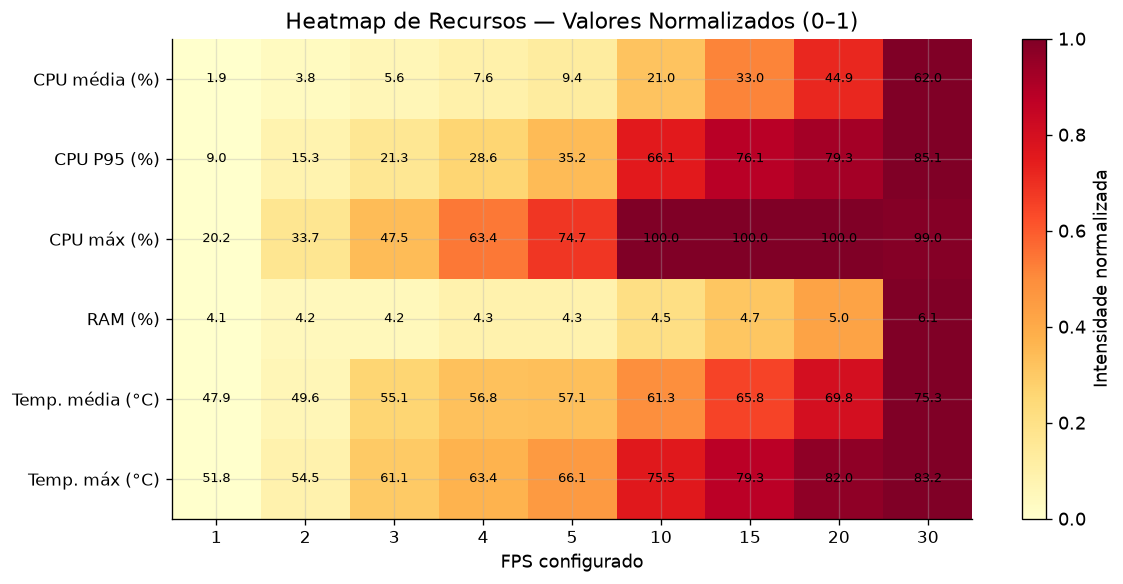

In [11]:
# ── 3c. Heatmap normalizado: FPS × métrica ───────────────────────────────
heatmap_cols = {
    "CPU média (%)":   "cpu_mean",
    "CPU P95 (%)":     "cpu_p95",
    "CPU máx (%)":     "cpu_max",
    "RAM (%)":         "ram_pct_mean",
    "Temp. média (°C)":"temp_mean",
    "Temp. máx (°C)":  "temp_max",
}

hm_data = df_summary.set_index("fps")[list(heatmap_cols.values())].copy()
hm_data.columns = list(heatmap_cols.keys())

# Normalização min-max por coluna
hm_norm = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min())

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(hm_norm.T, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(hm_norm)))
ax.set_xticklabels(hm_norm.index, fontsize=10)
ax.set_yticks(range(len(hm_norm.columns)))
ax.set_yticklabels(hm_norm.columns, fontsize=10)
ax.set_xlabel("FPS configurado")
ax.set_title("Heatmap de Recursos — Valores Normalizados (0–1)")

# Anotações com valor real
for i, fps in enumerate(hm_norm.index):
    for j, col in enumerate(hm_norm.columns):
        val = hm_data.loc[fps, col]
        ax.text(i, j, f"{val:.1f}", ha="center", va="center",
                fontsize=8, color="black")

plt.colorbar(im, ax=ax, label="Intensidade normalizada")
plt.tight_layout()
plt.savefig("fig3c_heatmap.pdf", bbox_inches="tight")
plt.show()


---
## 4. Latência e Throughput do Pipeline

**Pergunta central:** o pipeline consegue processar os frames em tempo real? Se o tempo total de predição de um animal excede o tempo de passagem desse animal, o pipeline está em **débito** — acumulando frames sem conseguir processá-los enquanto o animal ainda está presente.

> **Definições:**
> - **Tempo de passagem** (`passage_time_s`): intervalo entre a captura da 1ª e da última imagem do animal.
> - **Tempo de predição acumulado** (`pred_time_s`): soma dos intervalos de inferência de cada imagem adequada do animal.
> - **Pipeline em débito**: `pred_time_s > passage_time_s`


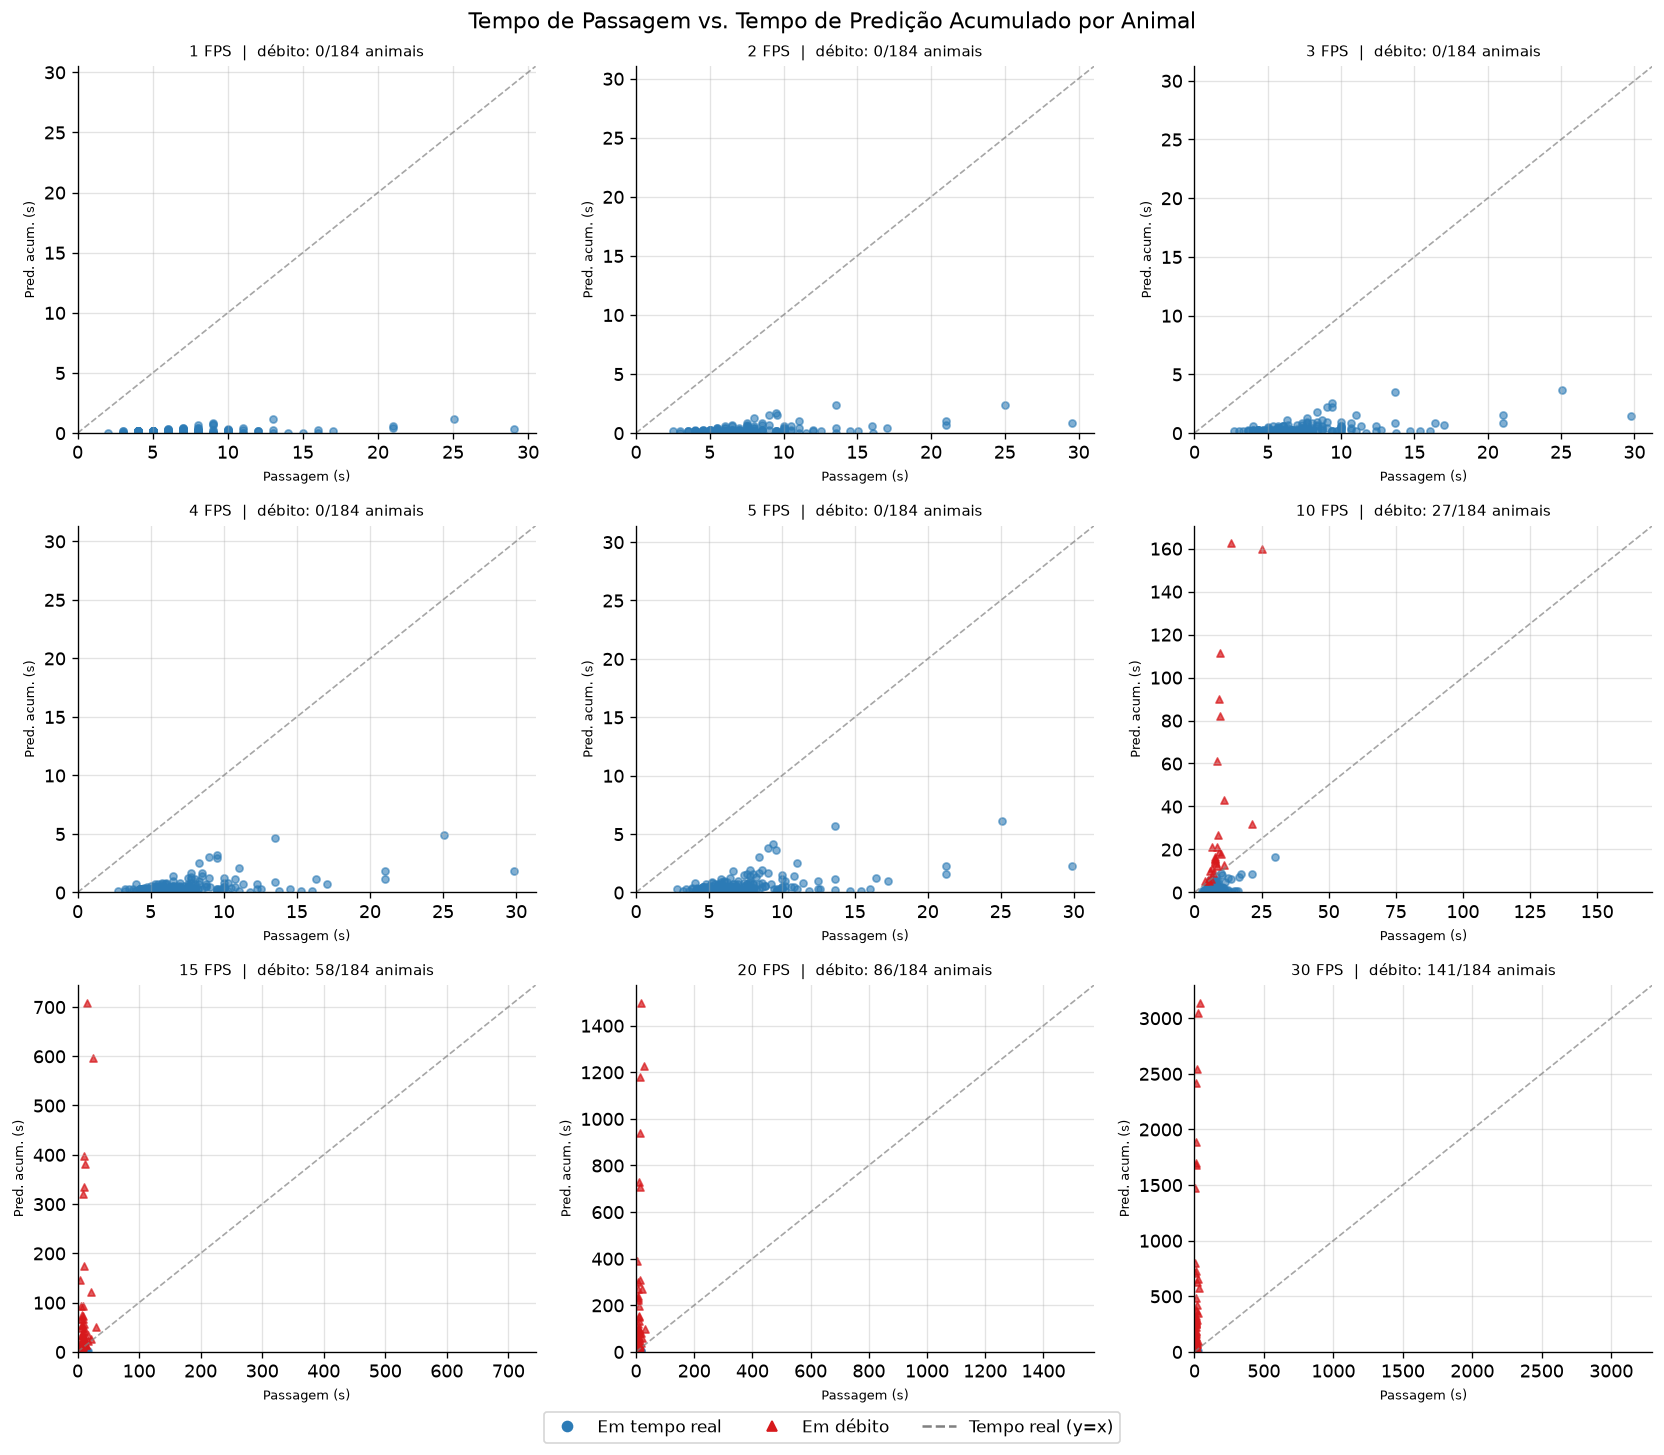

In [12]:
# ── 4a. Scatter: tempo de passagem × tempo de predição acumulado ─────────
#    Linha diagonal = pipeline exatamente em tempo real
#    Pontos ACIMA da diagonal = pipeline em débito

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, fps in zip(axes, fps_available):
    sub = df_animals[
        (df_animals["fps"] == fps) &
        df_animals["passage_time_s"].notna() &
        df_animals["pred_time_s"].notna()
    ]
    max_val = max(sub["passage_time_s"].max(), sub["pred_time_s"].max()) * 1.05

    in_debt = sub["pred_time_s"] > sub["passage_time_s"]

    ax.scatter(sub.loc[~in_debt, "passage_time_s"],
               sub.loc[~in_debt, "pred_time_s"],
               color="#2c7bb6", alpha=0.6, s=18, label="Em tempo real")
    ax.scatter(sub.loc[in_debt, "passage_time_s"],
               sub.loc[in_debt, "pred_time_s"],
               color="#d7191c", alpha=0.7, s=18, marker="^", label="Em débito")

    ax.plot([0, max_val], [0, max_val], "--", color="gray",
            linewidth=1, alpha=0.7)
    ax.set_title(f"{fps} FPS  |  débito: {in_debt.sum()}/{len(sub)} animais",
                 fontsize=9)
    ax.set_xlabel("Passagem (s)", fontsize=8)
    ax.set_ylabel("Pred. acum. (s)", fontsize=8)
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)

# Legenda global
handles = [
    Line2D([0],[0], marker="o", color="#2c7bb6", linestyle="none", label="Em tempo real"),
    Line2D([0],[0], marker="^", color="#d7191c", linestyle="none", label="Em débito"),
    Line2D([0],[0], linestyle="--", color="gray", label="Tempo real (y=x)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Tempo de Passagem vs. Tempo de Predição Acumulado por Animal",
             fontsize=13)
plt.tight_layout()
plt.savefig("fig4a_debt_scatter.pdf", bbox_inches="tight")
plt.show()


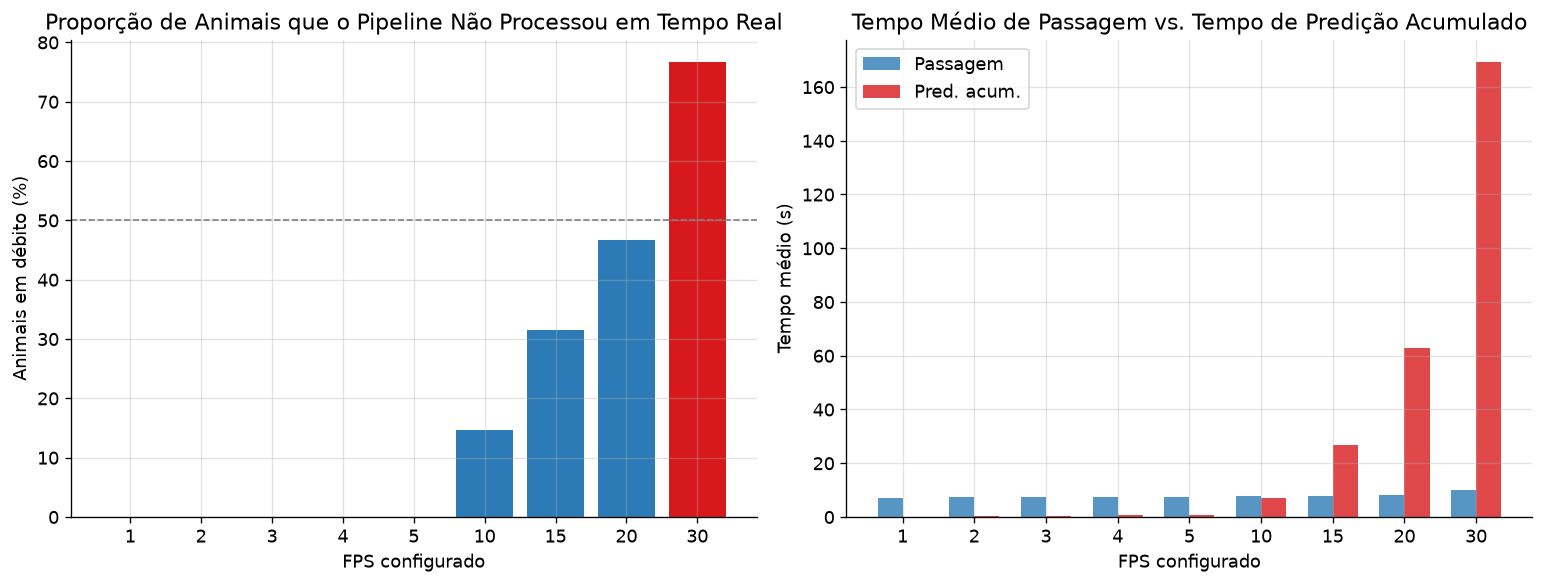

,fps,n_debt,n_total,pct_debt,pred_time_mean,passage_time_mean
0,1,0,184,0.00,0.14,7.15
1,2,0,184,0.00,0.28,7.42
2,3,0,184,0.00,0.41,7.51
3,4,0,184,0.00,0.55,7.54
4,5,0,184,0.00,0.68,7.59
5,10,27,184,14.67,7.12,7.66
6,15,58,184,31.52,26.92,7.82
7,20,86,184,46.74,62.90,8.23
8,30,141,184,76.63,169.17,10.05


In [15]:
# ── 4b. Proporção de animais em débito por FPS ───────────────────────────
debt_summary = []
for fps in fps_available:
    sub = df_animals[
        (df_animals["fps"] == fps) &
        df_animals["passage_time_s"].notna() &
        df_animals["pred_time_s"].notna()
    ]
    n_debt = (sub["pred_time_s"] > sub["passage_time_s"]).sum()
    n_total = len(sub)
    debt_summary.append({
        "fps": fps,
        "n_debt": n_debt,
        "n_total": n_total,
        "pct_debt": n_debt / n_total * 100,
        "pred_time_mean": sub["pred_time_s"].mean(),
        "passage_time_mean": sub["passage_time_s"].mean(),
    })

df_debt = pd.DataFrame(debt_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# % animais em débito
ax = axes[0]
colors = ["#d7191c" if p > 50 else "#2c7bb6" for p in df_debt["pct_debt"]]
ax.bar(df_debt["fps"].astype(str), df_debt["pct_debt"], color=colors)
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("FPS configurado")
ax.set_ylabel("Animais em débito (%)")
ax.set_title("Proporção de Animais que o Pipeline Não Processou em Tempo Real")

# Tempo médio de passagem vs. predição
ax = axes[1]
x = np.arange(len(df_debt))
w = 0.35
ax.bar(x - w/2, df_debt["passage_time_mean"], w, label="Passagem", color="#2c7bb6", alpha=0.8)
ax.bar(x + w/2, df_debt["pred_time_mean"],    w, label="Pred. acum.", color="#d7191c", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_debt["fps"].astype(str))
ax.set_xlabel("FPS configurado")
ax.set_ylabel("Tempo médio (s)")
ax.set_title("Tempo Médio de Passagem vs. Tempo de Predição Acumulado")
ax.legend()

plt.tight_layout()
plt.savefig("fig4b_debt_summary.pdf", bbox_inches="tight")
plt.show()
display(df_debt.round(2))


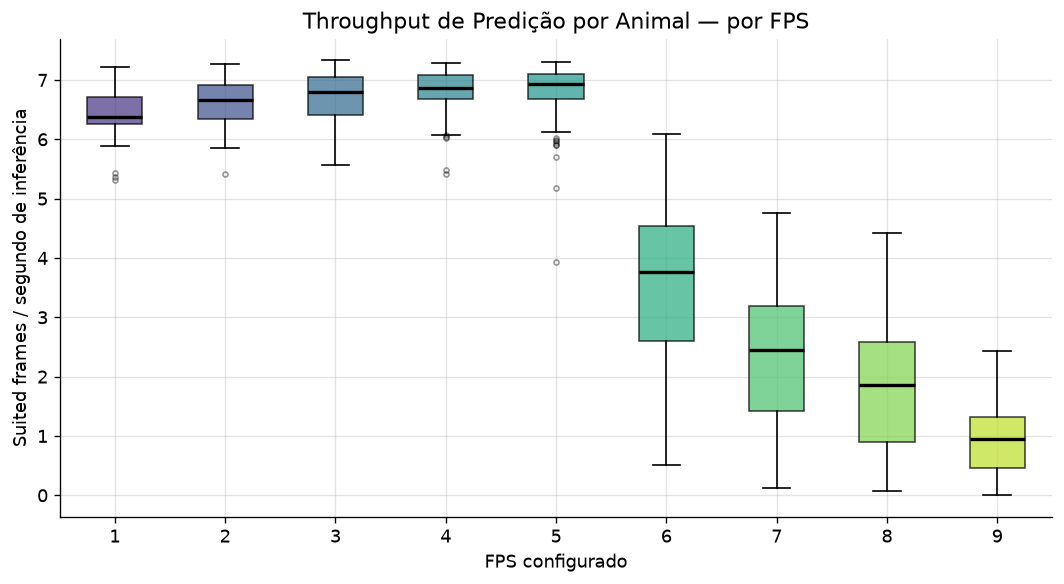

In [26]:
# ── 4c. Throughput: suited frames por segundo de inferência ───────────────
fig, ax = plt.subplots(figsize=(9, 5))

tp_by_fps = [
    df_animals.loc[df_animals["fps"] == fps, "throughput_suited_ps"].dropna().values
    for fps in fps_available
]

bp = ax.boxplot(
    tp_by_fps, label=fps_available,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
for patch, fps in zip(bp["boxes"], fps_available):
    patch.set_facecolor(FPS_COLOR[fps])
    patch.set_alpha(0.7)

ax.set_xlabel("FPS configurado")
ax.set_ylabel("Suited frames / segundo de inferência")
ax.set_title("Throughput de Predição por Animal — por FPS")
plt.tight_layout()
plt.savefig("fig4c_throughput.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# ANÁLISE DE LATÊNCIA DOS ANIMAIS EM DÉBITO
# ============================================================

,fps,animals,debt_animals,debt_pct,mean_latency,median_latency,p95_latency,max_latency,mean_suited,mean_total
0,1,184,0,0.000,1.005,1.005,1.008,1.013,0.946,8.141
1,2,184,0,0.000,0.503,0.503,0.511,0.514,1.924,15.810
2,3,184,0,0.000,0.340,0.339,0.346,0.351,2.853,23.462
3,4,184,0,0.000,0.260,0.259,0.267,0.431,3.837,31.071
4,5,184,0,0.000,0.213,0.212,0.221,0.414,4.750,38.815
5,10,184,27,14.674,0.199,0.121,0.577,2.853,9.554,77.027
6,15,184,58,31.522,0.599,0.103,3.639,9.951,14.288,115.228
7,20,184,86,46.739,1.479,0.110,9.748,17.574,19.033,153.484
8,30,184,141,76.630,13.904,16.287,30.810,47.514,28.516,229.946


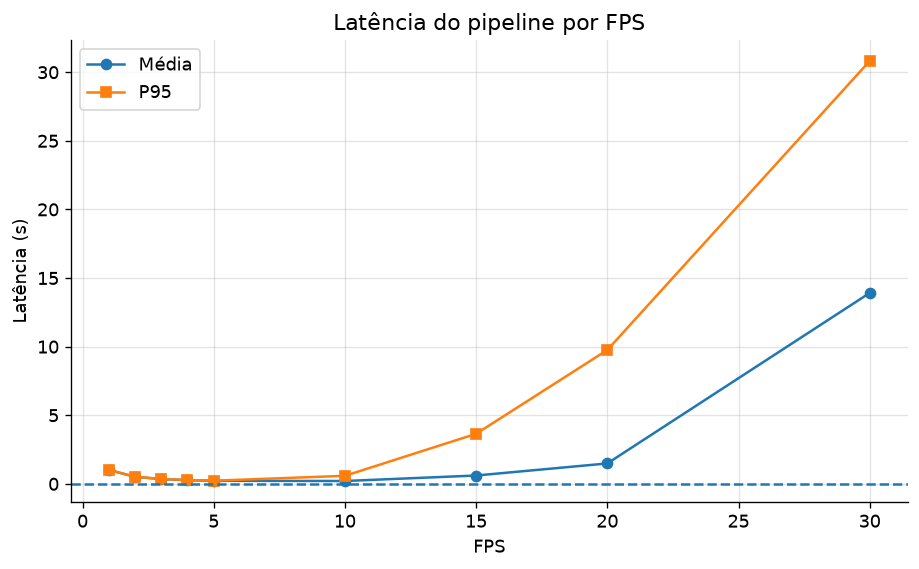

<Figure size 1200x600 with 0 Axes>

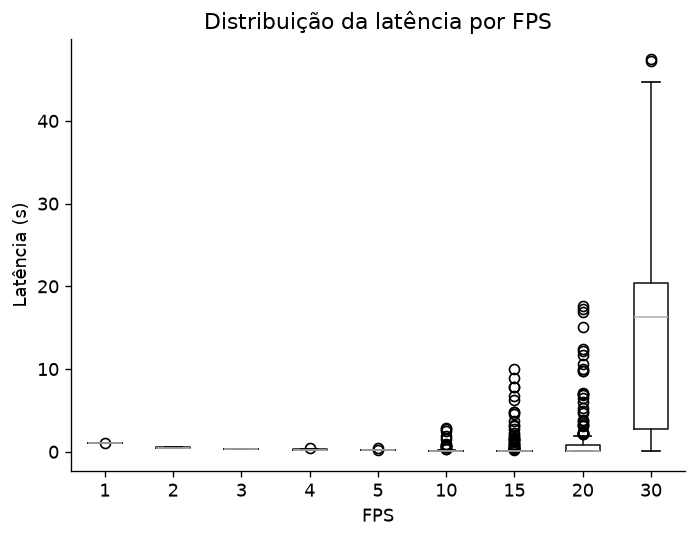


COMPARAÇÃO ENTRE ANIMAIS COM E SEM DÉBITO



,animals,suited_mean,suited_median,total_mean
in_debt,,,,
False,1344,4.13,3.0,52.75
True,312,32.76,21.0,181.46



CORRELAÇÕES
latência x suited_images : 0.492
latência x total_images  : 0.485
latência x passage_time  : 0.229


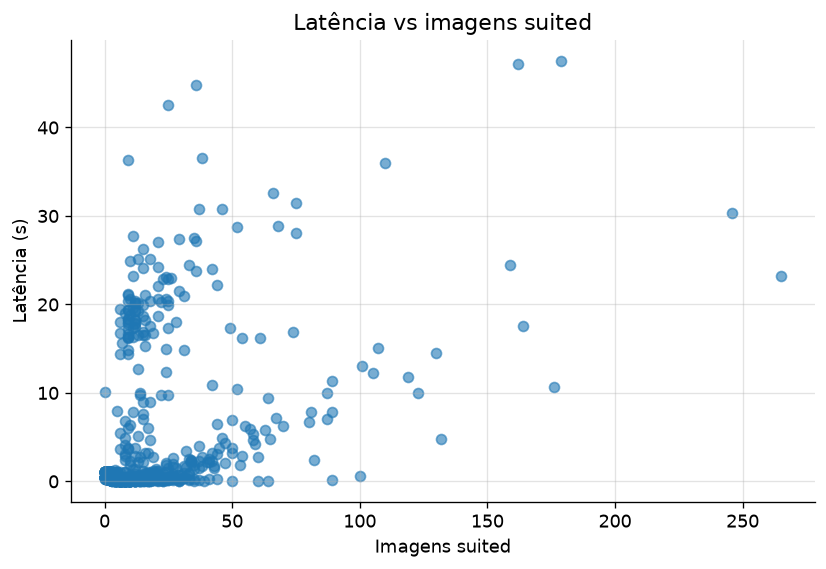

In [6]:
lat_df = df_animals.copy()

# ------------------------------------------------------------
# Latência
# ------------------------------------------------------------

lat_df["latency_s"] = (
    lat_df["total_animal_time_s"]
    - lat_df["passage_time_s"]
)

lat_df["in_debt"] = lat_df["pred_time_s"] > lat_df["passage_time_s"]

# ------------------------------------------------------------
# Resumo por FPS
# ------------------------------------------------------------

lat_summary = (
    lat_df
    .groupby("fps")
    .agg(
        animals=("animal_id", "count"),
        debt_animals=("in_debt", "sum"),
        debt_pct=("in_debt", "mean"),

        mean_latency=("latency_s", "mean"),
        median_latency=("latency_s", "median"),

        p95_latency=("latency_s",
                     lambda x: np.percentile(x, 95)),

        max_latency=("latency_s", "max"),

        mean_suited=("suited_images", "mean"),
        mean_total=("total_images", "mean")
    )
    .reset_index()
)

lat_summary["debt_pct"] *= 100

display(lat_summary.round(3))

# ------------------------------------------------------------
# Latência média e P95
# ------------------------------------------------------------

plt.figure(figsize=(9,5))

plt.plot(
    lat_summary["fps"],
    lat_summary["mean_latency"],
    marker="o",
    label="Média"
)

plt.plot(
    lat_summary["fps"],
    lat_summary["p95_latency"],
    marker="s",
    label="P95"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("FPS")
plt.ylabel("Latência (s)")
plt.title("Latência do pipeline por FPS")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Distribuição da latência
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

lat_df.boxplot(
    column="latency_s",
    by="fps",
    grid=False
)

plt.title("Distribuição da latência por FPS")
plt.suptitle("")
plt.xlabel("FPS")
plt.ylabel("Latência (s)")

plt.show()

# ------------------------------------------------------------
# Débito x quantidade de imagens suited
# ------------------------------------------------------------

debt_compare = (
    lat_df
    .groupby("in_debt")
    .agg(
        animals=("animal_id", "count"),
        suited_mean=("suited_images", "mean"),
        suited_median=("suited_images", "median"),
        total_mean=("total_images", "mean")
    )
)

print("\nCOMPARAÇÃO ENTRE ANIMAIS COM E SEM DÉBITO\n")
display(debt_compare.round(2))

# ------------------------------------------------------------
# Correlações
# ------------------------------------------------------------

corr_suited = (
    lat_df["latency_s"]
    .corr(lat_df["suited_images"])
)

corr_total = (
    lat_df["latency_s"]
    .corr(lat_df["total_images"])
)

corr_passage = (
    lat_df["latency_s"]
    .corr(lat_df["passage_time_s"])
)

print("\nCORRELAÇÕES")
print(f"latência x suited_images : {corr_suited:.3f}")
print(f"latência x total_images  : {corr_total:.3f}")
print(f"latência x passage_time  : {corr_passage:.3f}")

# ------------------------------------------------------------
# Scatter principal
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    lat_df["suited_images"],
    lat_df["latency_s"],
    alpha=0.6
)

plt.xlabel("Imagens suited")
plt.ylabel("Latência (s)")
plt.title("Latência vs imagens suited")

plt.grid(True)

plt.show()

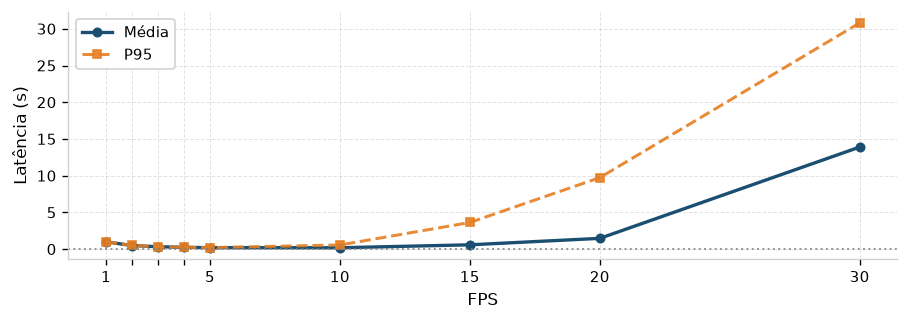

In [7]:
# ------------------------------------------------------------
# Gráfico de Latência Otimizado (Panorâmico para 1 Coluna)
# Fontes aumentadas em +1pt
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# --- PADRÕES DE FONTE (+1 pt em relação ao original) ---
TITLE_FONT  = 11
LABEL_FONT  = 10
TICK_FONT   = 9
LEGEND_FONT = 9

fps_vals = lat_summary["fps"].values

C_MEAN = "#1b4f72"   
C_P95  = "#e67e22"   

# Largura 7.5 polegadas (wide) igual ao gráfico de Trade-off
fig, ax = plt.subplots(
    figsize=(7.5, 2.6) 
)

# Plot Média 
ax.plot(
    fps_vals, 
    lat_summary["mean_latency"],
    label="Média",
    linestyle="-",
    marker="o",
    linewidth=2.0, 
    alpha=1.00,
    color=C_MEAN,
    markersize=5,
)

# Plot P95
ax.plot(
    fps_vals, 
    lat_summary["p95_latency"],
    label="P95",
    linestyle="--",
    marker="s",
    linewidth=1.8,
    alpha=0.90,
    color=C_P95,
    markersize=5,
)

ax.axhline(0, linestyle=":", color="gray", linewidth=1.2, alpha=0.8)

# Eixos com os mesmos padrões de fonte
ax.set_xlabel("FPS", fontsize=LABEL_FONT)
ax.set_ylabel("Latência (s)", fontsize=LABEL_FONT)

ax.set_xticks(fps_vals)
ax.set_xticklabels([
    "1",
    "",
    "",
    "",
    "5",
    "10",
    "15",
    "20",
    "30",
])

ax.tick_params(axis="both", labelsize=TICK_FONT)

ax.grid(True, linestyle="--", alpha=0.35, linewidth=0.6)
for spine in ax.spines.values():
    spine.set_color("#d0d0d0")

ax.legend(
    fontsize=LEGEND_FONT, 
    frameon=True, 
    framealpha=0.95, 
    edgecolor="#d0d0d0", 
    loc="best"
)

plt.tight_layout(pad=0.4)
plt.savefig(
    "fig4_latency_vs_fps.pdf", 
    format="pdf", 
    bbox_inches="tight", 
    pad_inches=0.01
)
plt.show()


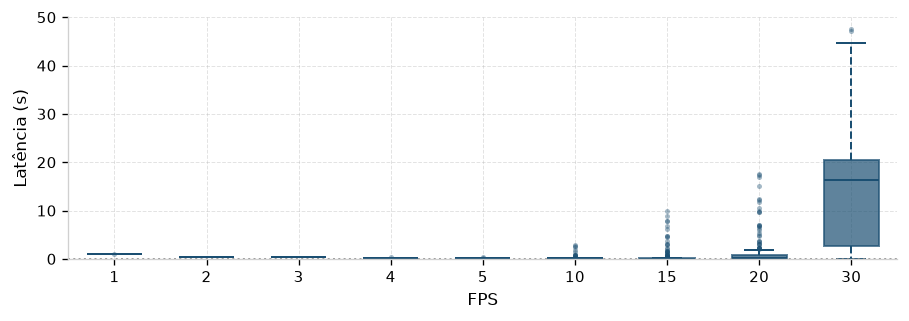

In [9]:
# ------------------------------------------------------------
# Gráfico de Latência em Boxplot (Panorâmico para 1 Coluna)
# Eixo X espaçado igualmente (categórico) e Eixo Y máx = 30
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# --- PADRÕES DE FONTE (+1 pt) ---
TITLE_FONT  = 11
LABEL_FONT  = 10
TICK_FONT   = 9
LEGEND_FONT = 9

C_BOX = "#1b4f72" # azul petróleo (caixas e mediana)

fig, ax = plt.subplots(figsize=(7.5, 2.6))

# ------------------------------------------------------------
# PREPARAÇÃO DOS DADOS BRUTOS 
# ------------------------------------------------------------
fps_vals = lat_summary["fps"].values
dados_por_fps = []

for f in fps_vals:
    # Coleta todas as latências brutas
    latencias = lat_df[lat_df["fps"] == f]["latency_s"].dropna().values
    dados_por_fps.append(latencias)

# ------------------------------------------------------------
# PLOTAGEM DO BOXPLOT
# Sem o parâmetro 'positions', o matplotlib espaça igualmente!
# ------------------------------------------------------------
box = ax.boxplot(
    dados_por_fps,
    widths=0.6, # Caixas um pouco mais finas para compensar o espaçamento igual
    patch_artist=True, 
    # Estilização
    boxprops=dict(facecolor=C_BOX, color=C_BOX, alpha=0.7, linewidth=1.2),
    capprops=dict(color=C_BOX, linewidth=1.2),
    whiskerprops=dict(color=C_BOX, linewidth=1.2, linestyle="--"),
    flierprops=dict(marker="o", markerfacecolor=C_BOX, markeredgecolor="none", markersize=3, alpha=0.4),
    medianprops=dict(color=C_BOX, linewidth=1.2) # Mediana normal, na mesma cor da caixa
)

ax.axhline(0, linestyle=":", color="gray", linewidth=1.2, alpha=0.8)

# Eixos
ax.set_xlabel("FPS", fontsize=LABEL_FONT)
ax.set_ylabel("Latência (s)", fontsize=LABEL_FONT)

# Define o limite máximo do eixo Y em 30
ax.set_ylim(0, 50)

# O matplotlib coloca as caixas nas posições 1, 2, 3... 9.
# Aqui nós dizemos que os textos dessas posições serão "1", "2", "3", "5", "10"...
ax.set_xticks(range(1, len(fps_vals) + 1))
ax.set_xticklabels([str(v) for v in fps_vals])

ax.tick_params(axis="both", labelsize=TICK_FONT)
ax.grid(True, linestyle="--", alpha=0.35, linewidth=0.6)

for spine in ax.spines.values():
    spine.set_color("#d0d0d0")

plt.tight_layout(pad=0.4)
plt.savefig(
    "fig4_latency_boxplot.pdf", 
    format="pdf", 
    bbox_inches="tight", 
    pad_inches=0.01
)
plt.show()


---
## 5. Trade-off Central: Suited Frames vs. Consumo de Recursos

Esta é a figura principal do TCC. Ela coloca lado a lado o **ganho de informação** (suited frames por animal) e o **custo computacional** (CPU média) em função do FPS, tornando visível o ponto a partir do qual o incremento de frames adequados não justifica o aumento de consumo.


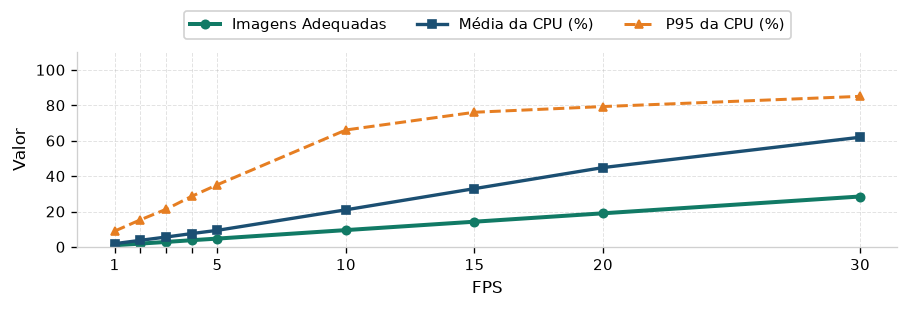

In [38]:
# ------------------------------------------------------------
# Figura: Trade-off entre Benefício e Custo Computacional
# Preparada para artigo SBC / Overleaf
# Layout Panorâmico (Widescreen) para 1 Coluna
# Fontes aumentadas em +1pt
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# --- PADRÕES DE FONTE (+1 pt em relação ao anterior) ---
TITLE_FONT  = 11
LABEL_FONT  = 10
TICK_FONT   = 9
LEGEND_FONT = 9

fps_vals = df_summary["fps"].values

# ------------------------------------------------------------
# Cores (consistentes com as demais figuras)
# ------------------------------------------------------------

C_SUITED = "#117a65"   # verde escuro
C_CPU    = "#1b4f72"   # azul petróleo
C_P95    = "#e67e22"   # laranja queimado

# ------------------------------------------------------------
# Figura (Panorâmica: Larga e Achatada)
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.5, 2.6) 
)

# ------------------------------------------------------------
# Benefício (Imagens Adequadas)
# ------------------------------------------------------------

ax.plot(
    fps_vals,
    df_summary["suited_imgs_mean"],
    label="Imagens Adequadas",
    color=C_SUITED,
    linewidth=2.4,
    marker="o",
    markersize=5,
)

# ------------------------------------------------------------
# Custo (CPU)
# ------------------------------------------------------------

ax.plot(
    fps_vals,
    df_summary["cpu_mean"],
    label="Média da CPU (%)",
    color=C_CPU,
    linewidth=2.0,
    linestyle="-",
    marker="s",
    markersize=5,
)

ax.plot(
    fps_vals,
    df_summary["cpu_p95"],
    label="P95 da CPU (%)",
    color=C_P95,
    linewidth=1.8,
    linestyle="--",
    marker="^",
    markersize=5,
)

# ------------------------------------------------------------
# Eixos
# ------------------------------------------------------------

ax.set_xlabel(
    "FPS",
    fontsize=LABEL_FONT
)

ax.set_ylabel(
    "Valor",
    fontsize=LABEL_FONT
)

ax.set_ylim(0, 110)

ax.set_xticks(fps_vals)

ax.set_xticklabels([
    "1",
    "",
    "",
    "",
    "5",
    "10",
    "15",
    "20",
    "30",
])

ax.tick_params(
    axis="both",
    labelsize=TICK_FONT
)

# ------------------------------------------------------------
# Estilo
# ------------------------------------------------------------

ax.grid(
    True,
    linestyle="--",
    alpha=0.35,
    linewidth=0.6
)

for spine in ax.spines.values():
    spine.set_color("#d0d0d0")

# Legenda horizontal no topo
ax.legend(
    fontsize=LEGEND_FONT,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25), 
    frameon=True,
    framealpha=0.95,
    edgecolor="#d0d0d0",
)

plt.tight_layout(pad=0.4)

plt.savefig(
    "fig5_tradeoff_main.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.show()


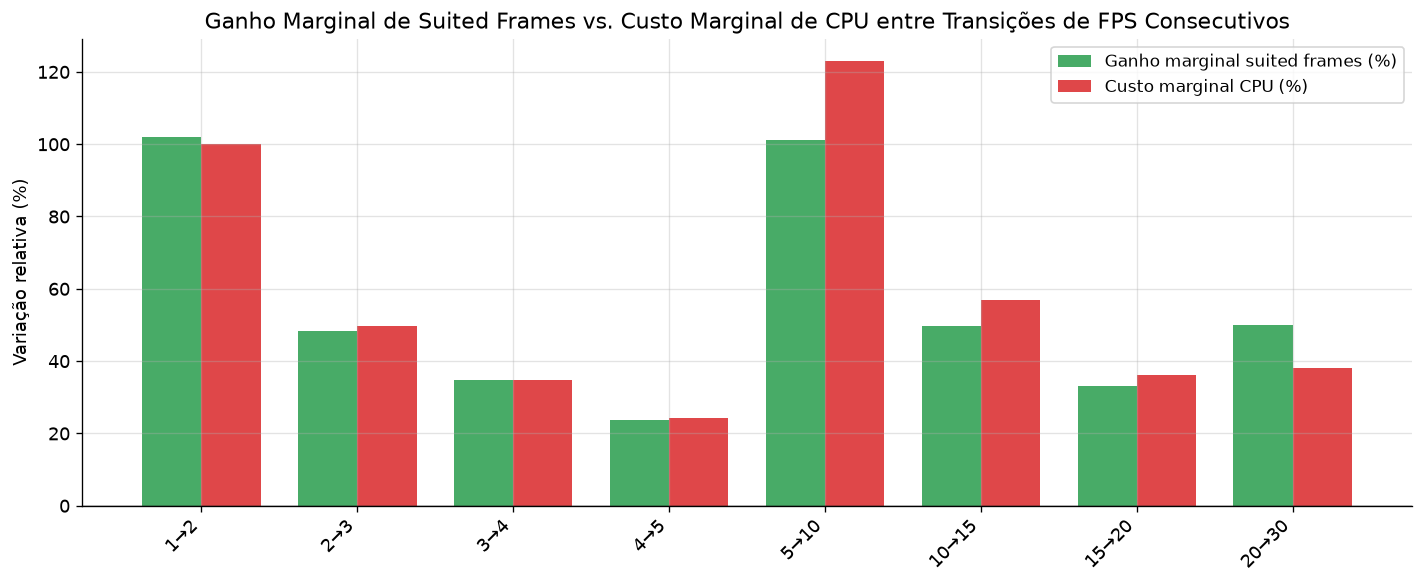


Tabela de ganhos marginais:


,Transição FPS,Ganho suited frames (%),Custo CPU (%),Razão ganho/custo
0,1→2,102.11,100.00,1.02
1,2→3,48.44,49.73,0.97
2,3→4,34.74,34.64,1.00
3,4→5,23.70,24.27,0.98
4,5→10,101.05,123.04,0.82
5,10→15,49.63,56.93,0.87
6,15→20,33.17,36.06,0.92
7,20→30,49.87,38.16,1.31


In [21]:
# ── 5b. Ganho marginal relativo: suited frames vs CPU ────────────────────
suited_arr = df_summary["suited_imgs_mean"].values
cpu_arr    = df_summary["cpu_mean"].values

# Ganho/custo marginal relativo entre FPS consecutivos (%)
gain_suited = np.diff(suited_arr) / suited_arr[:-1] * 100
cost_cpu    = np.diff(cpu_arr)    / cpu_arr[:-1]    * 100

labels_trans = [f"{fps_vals[i]}→{fps_vals[i+1]}" for i in range(len(fps_vals)-1)]
x = np.arange(len(labels_trans))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, gain_suited, w, label="Ganho marginal suited frames (%)",
       color=color_suited, alpha=0.8)
ax.bar(x + w/2, cost_cpu,    w, label="Custo marginal CPU (%)",
       color=color_cpu, alpha=0.8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_trans, rotation=45, ha="right")
ax.set_ylabel("Variação relativa (%)")
ax.set_title("Ganho Marginal de Suited Frames vs. Custo Marginal de CPU entre Transições de FPS Consecutivos")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig5b_marginal.pdf", bbox_inches="tight")
plt.show()

# Tabela de ganhos marginais
df_marginal = pd.DataFrame({
    "Transição FPS":              labels_trans,
    "Ganho suited frames (%)":    np.round(gain_suited, 2),
    "Custo CPU (%)":              np.round(cost_cpu, 2),
    "Razão ganho/custo":          np.round(gain_suited / np.where(cost_cpu != 0, cost_cpu, np.nan), 2),
})
print("\nTabela de ganhos marginais:")
display(df_marginal)


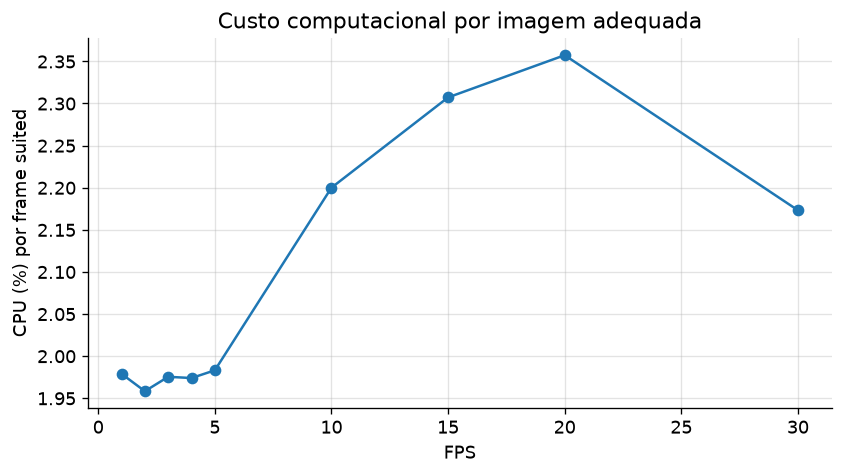

,fps,cpu_mean,suited_imgs_mean,cpu_per_suited
0,1,1.88,0.95,1.978947
1,2,3.76,1.92,1.958333
2,3,5.63,2.85,1.975439
3,4,7.58,3.84,1.973958
4,5,9.42,4.75,1.983158
5,10,21.01,9.55,2.200000
6,15,32.97,14.29,2.307208
7,20,44.86,19.03,2.357331
8,30,61.98,28.52,2.173212


In [33]:
# ============================================================
# CUSTO COMPUTACIONAL POR FRAME ÚTIL
# ============================================================

df_summary["cpu_per_suited"] = (
    df_summary["cpu_mean"]
    / df_summary["suited_imgs_mean"]
)

plt.figure(figsize=(8,4))

plt.plot(
    df_summary["fps"],
    df_summary["cpu_per_suited"],
    marker="o"
)

plt.xlabel("FPS")
plt.ylabel("CPU (%) por frame suited")
plt.title("Custo computacional por imagem adequada")
plt.grid(True)

plt.show()

display(
    df_summary[
        [
            "fps",
            "cpu_mean",
            "suited_imgs_mean",
            "cpu_per_suited"
        ]
    ]
)

,from_fps,to_fps,gain_suited,extra_cpu,efficiency
0,1,2,0.97,1.88,0.515957
1,2,3,0.93,1.87,0.497326
2,3,4,0.99,1.95,0.507692
3,4,5,0.91,1.84,0.494565
4,5,10,4.80,11.59,0.414150
5,10,15,4.74,11.96,0.396321
6,15,20,4.74,11.89,0.398654
7,20,30,9.49,17.12,0.554322


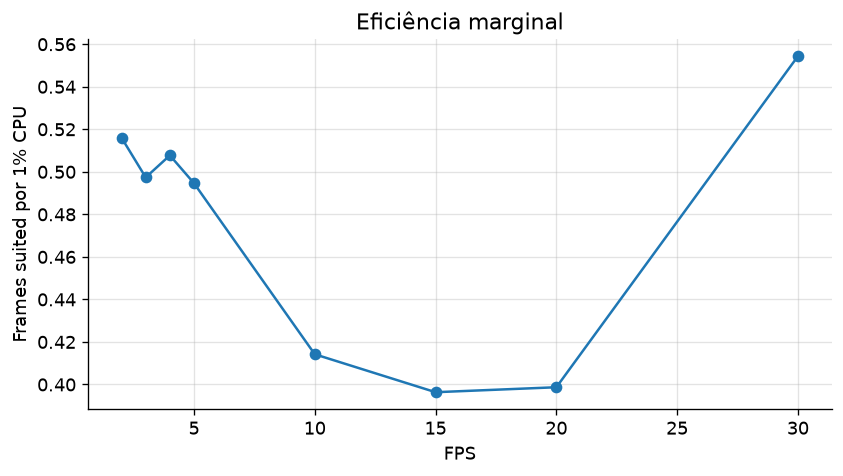

In [35]:
# ============================================================
# EFICIÊNCIA INCREMENTAL
# ============================================================

delta_cpu = np.diff(df_summary["cpu_mean"])
delta_suited = np.diff(df_summary["suited_imgs_mean"])

efficiency = delta_suited / delta_cpu

eff_df = pd.DataFrame({
    "from_fps": df_summary["fps"][:-1].values,
    "to_fps": df_summary["fps"][1:].values,
    "gain_suited": delta_suited,
    "extra_cpu": delta_cpu,
    "efficiency": efficiency
})

display(eff_df)

plt.figure(figsize=(8,4))

plt.plot(
    eff_df["to_fps"],
    eff_df["efficiency"],
    marker="o"
)

plt.xlabel("FPS")
plt.ylabel("Frames suited por 1% CPU")
plt.title("Eficiência marginal")
plt.grid(True)

plt.show()

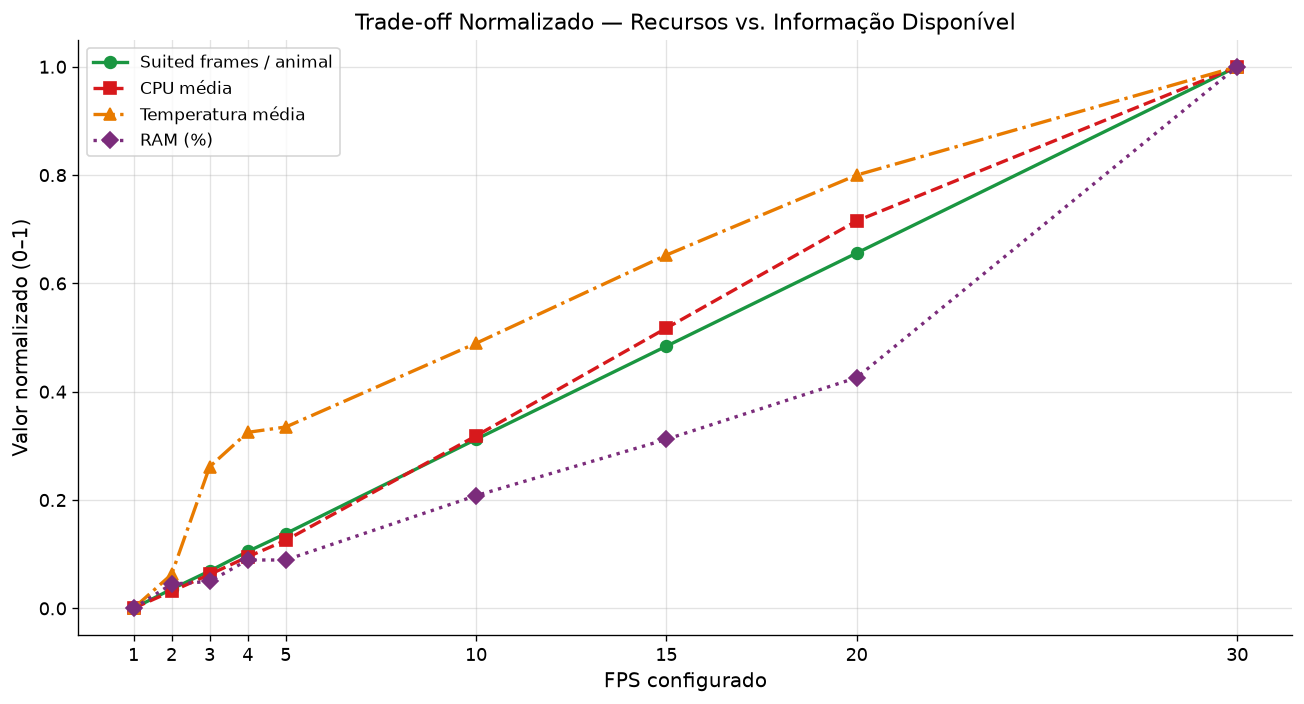

In [22]:
# ── 5c. Trade-off completo: 4 métricas normalizadas em um gráfico ─────────
fig, ax = plt.subplots(figsize=(11, 6))

metrics_norm_cfg = [
    ("suited_imgs_mean", "Suited frames / animal", "#1a9641", "o", "-"),
    ("cpu_mean",         "CPU média",              "#d7191c", "s", "--"),
    ("temp_mean",        "Temperatura média",      "#e87b00", "^", "-."),
    ("ram_pct_mean",     "RAM (%)",                "#7b2c7b", "D", ":"),
]

for col, label, color, marker, ls in metrics_norm_cfg:
    vals = df_summary[col].values.astype(float)
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min())
    ax.plot(fps_vals, vals_norm, marker=marker, color=color,
            linestyle=ls, linewidth=2, label=label, markersize=7)

ax.set_xlabel("FPS configurado", fontsize=12)
ax.set_ylabel("Valor normalizado (0–1)", fontsize=12)
ax.set_title("Trade-off Normalizado — Recursos vs. Informação Disponível", fontsize=13)
ax.set_xticks(fps_vals)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig5c_tradeoff_normalized.pdf", bbox_inches="tight")
plt.show()


---
## 6. Tabela de Resultados Consolidada

Resumo completo de todas as métricas por FPS para referência e inclusão no texto do TCC.


In [23]:
# Construção da tabela final
df_final = df_summary[[
    "fps",
    "n_animals",
    "total_imgs_mean",
    "suited_imgs_mean",
    "conversion_mean",
    "cpu_mean",
    "cpu_max",
    "ram_pct_mean",
    "temp_mean",
    "temp_max",
    "duration_s",
]].copy()

df_final.columns = [
    "FPS",
    "Animais",
    "Total imgs/animal (média)",
    "Suited imgs/animal (média)",
    "Taxa conversão (média)",
    "CPU média (%)",
    "CPU máx (%)",
    "RAM (%)",
    "Temp. média (°C)",
    "Temp. máx (°C)",
    "Duração execução (s)",
]

df_final["Taxa conversão (média)"] = (df_final["Taxa conversão (média)"] * 100).round(1)
df_final = df_final.round(2)

# Adiciona coluna de débito
df_final = df_final.merge(
    df_debt[["fps", "pct_debt"]].rename(columns={"pct_debt": "Animais em débito (%)"}),
    left_on="FPS", right_on="fps", how="left"
).drop(columns="fps")
df_final["Animais em débito (%)"] = df_final["Animais em débito (%)"].round(1)

display(df_final)

# Exporta para CSV
df_final.to_csv("tabela_resultados_tcc1.csv", index=False)
print("\nTabela exportada: tabela_resultados_tcc1.csv")


,FPS,Animais,Total imgs/animal (média),Suited imgs/animal (média),Taxa conversão (média),CPU média (%),CPU máx (%),RAM (%),Temp. média (°C),Temp. máx (°C),Duração execução (s),Animais em débito (%)
0,1,184,8.14,0.95,11.0,1.88,20.2,4.11,47.92,51.80,1686.16,0.0
1,2,184,15.81,1.92,12.0,3.76,33.7,4.20,49.63,54.55,1551.18,0.0
2,3,184,23.46,2.85,12.0,5.63,47.5,4.21,55.07,61.15,1505.25,0.0
3,4,184,31.07,3.84,12.0,7.58,63.4,4.29,56.81,63.35,1480.78,0.0
4,5,184,38.82,4.75,12.0,9.42,74.7,4.29,57.08,66.10,1472.32,0.0
5,10,184,77.03,9.55,12.0,21.01,100.0,4.53,61.31,75.45,1447.36,14.7
6,15,184,115.23,14.29,12.0,32.97,100.0,4.74,65.77,79.30,1465.47,31.5
7,20,184,153.48,19.03,12.0,44.86,100.0,4.97,69.81,82.05,1535.54,46.7
8,30,184,229.95,28.52,12.0,61.98,99.0,6.13,75.29,83.15,1875.86,76.6



Tabela exportada: tabela_resultados_tcc1.csv


---
## 7. Síntese e Interpretação

Esta célula imprime automaticamente os principais achados numéricos para apoiar a redação do TCC.


In [24]:
print("=" * 60)
print("SÍNTESE DOS RESULTADOS — TCC I")
print("=" * 60)

# Saturação de suited frames
max_suited = df_summary["suited_imgs_mean"].max()
fps_saturation = df_summary.loc[
    df_summary["suited_imgs_mean"] >= 0.95 * max_suited, "fps"
].min()
print(f"\n• Máximo de suited frames/animal: {max_suited:.2f}")
print(f"• FPS a partir do qual suited frames ≥ 95% do máximo: {fps_saturation} FPS")

# Crescimento de CPU
cpu_1fps  = df_summary.loc[df_summary["fps"] == fps_available[0],  "cpu_mean"].values[0]
cpu_max_v = df_summary["cpu_mean"].max()
fps_cpu_max = df_summary.loc[df_summary["cpu_mean"].idxmax(), "fps"]
print(f"\n• CPU média em {fps_available[0]} FPS: {cpu_1fps:.1f}%")
print(f"• CPU média máxima: {cpu_max_v:.1f}% em {fps_cpu_max} FPS")
print(f"• Crescimento total de CPU: {(cpu_max_v/cpu_1fps - 1)*100:.0f}%")

# Temperatura
temp_max_val = df_summary["temp_max"].max()
fps_temp_max = df_summary.loc[df_summary["temp_max"].idxmax(), "fps"]
print(f"\n• Temperatura máxima registrada: {temp_max_val:.1f}°C em {fps_temp_max} FPS")

# Melhor razão ganho/custo
best_idx = df_marginal["Razão ganho/custo"].idxmax()
best_trans = df_marginal.loc[best_idx, "Transição FPS"]
best_ratio = df_marginal.loc[best_idx, "Razão ganho/custo"]
print(f"\n• Melhor razão ganho-custo (suited/CPU): {best_ratio:.2f}x na transição {best_trans} FPS")

# Débito
fps_no_debt = [
    row["fps"] for _, row in df_debt.iterrows() if row["pct_debt"] == 0
]
fps_first_debt = df_debt.loc[df_debt["pct_debt"] > 0, "fps"].min()
print(f"\n• FPS sem nenhum animal em débito: {fps_no_debt}")
print(f"• Primeiro FPS com animais em débito: {fps_first_debt} FPS")

print("\n" + "=" * 60)


SÍNTESE DOS RESULTADOS — TCC I

• Máximo de suited frames/animal: 28.52
• FPS a partir do qual suited frames ≥ 95% do máximo: 30 FPS

• CPU média em 1 FPS: 1.9%
• CPU média máxima: 62.0% em 30 FPS
• Crescimento total de CPU: 3197%

• Temperatura máxima registrada: 83.2°C em 30 FPS

• Melhor razão ganho-custo (suited/CPU): 1.31x na transição 20→30 FPS

• FPS sem nenhum animal em débito: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
• Primeiro FPS com animais em débito: 10 FPS

